[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_01/MFM_ch1_seminar_tests/MFM_ch1_seminar_tests.ipynb)

# MFM_ch1_seminar_tests

Seminar 1 computations and charts: a first look at BET-TR, Bitcoin and EUR/RON with dated extremes; return arithmetic (A1), the variance ratio of an AR(1) (A2), chi-square reference distributions for Jarque-Bera and Ljung-Box (A3), drawdown arithmetic and the expected maximum drawdown of a Brownian log price (A4), an illustrative OHLC day (A5), a two-state volatility mixture (A6) and Markov regimes (A8), the Hill estimator step by step and on simulated Student-t data (A7, A11), Gaussian GARCH kurtosis and residual QQ plot (A9); descriptive statistics and their sensitivity to extreme days (B1), VaR 1% under three distributions (B2), autocorrelation of returns and of their size (B3), non-overlapping aggregation (B4), leverage correlations and the leverage regression with Newey-West errors (B5, B12), EUR/RON regimes and a CUSUM variance break (B6), BET-TR vs S&P 500 performance, the Sharpe difference bootstrap and asynchronous closes (B7, B13), range-based estimators on the index and on SPY (B8), classical vs heteroskedasticity-robust Ljung-Box (B9), expanding-window kurtosis vs simulated Student-t bands (B10), Hill plots on both tails (B11), a GARCH(1,1)-t check of stylised facts (B14), long memory before and after a variance break (B15), the BET-TR autocorrelation before and after the 2020 FTSE Russell reclassification (C1) and the corrected AI answer (C2).

*Modelling Financial Markets (MFM), Chapter 1: Stylised Facts and Returns. Author: Daniel Traian Pele.*

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_1'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import warnings
warnings.filterwarnings('ignore')
import sys
if 'google.colab' in sys.modules:
    !pip -q install arch
import statsmodels.api as sm

## Style and helpers

In [2]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
Teal     = '#17A2B8'

ASSETS = ['sp500', 'bettr', 'btc', 'eurron', 'gold']
COLORS = {'sp500': MainBlue, 'bettr': IDAred, 'btc': Amber, 'eurron': Forest, 'gold': Purple}
PERIODS = {'sp500': 252, 'bettr': 252, 'btc': 365, 'eurron': 252, 'gold': 252}


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


## Data

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')

SOURCES = {
    'sp500':  ('GSPC.INDX',    'close', '1990-01-01'),
    'bettr':  ('BETTR.INDX',   'close', '2014-09-01'),
    'btc':    ('BTC-USD.CC',   'close', '2014-09-17'),
    'eurron': ('REF:EUR',      'close', '2005-07-01'),   # de la introducerea leului nou (RON), 1 iulie 2005
    'gold':   ('XAUUSD.FOREX', 'close', '1990-01-01'),
}

LABELS = {'sp500': 'S&P 500', 'bettr': 'BET-TR (Romania)', 'btc': 'Bitcoin',
          'eurron': 'EUR/RON', 'gold': 'Gold'}

# cotatii OTC (aur): sesiunile partiale de sambata/duminica rup randamentul vineri -> luni,
# deci pastram doar zilele lucratoare (aceeasi conventie ca in Capitolul 0)
WEEKDAYS_ONLY = {'gold'}

_CACHE = {}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    df = pd.read_csv(src, parse_dates=['date']).set_index('date').sort_index()
    df.index.name = 'Date'
    return df


def read_reference_rate(currency='EUR', start='2005-07-01', end='2026-09-18'):
    """Cursul oficial de referinta RON (arhive XML anuale BNR)."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    import re
    import urllib.request
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    df = pd.DataFrame(rows, columns=['Date', 'Close']).drop_duplicates('Date').set_index('Date')
    df.index = pd.to_datetime(df.index)
    _CACHE[key] = df.sort_index().loc[start:end]
    return _CACHE[key]


def load_data(name='sp500'):
    """OHLCV zilnic cu coloane Open/High/Low/Close/Volume (Close = pretul folosit)."""
    symbol, col, start = SOURCES[name]
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start)
    d = read_market(symbol).loc[start:]
    if name in WEEKDAYS_ONLY:
        d = d[d.index.dayofweek < 5]
    out = pd.DataFrame({'Open': d['open'], 'High': d['high'], 'Low': d['low'],
                        'Close': d[col], 'Volume': d['volume']})
    return out[out['Close'] > 0].dropna(subset=['Close'])


def load_close(name):
    """Pretul de inchidere, folosit in toate graficele."""
    return load_data(name)['Close'].dropna()


closes = {a: load_close(a) for a in ASSETS}
rets = {a: np.log(c).diff().dropna() for a, c in closes.items()}
# gold (weekdays only) is annualised with its actual number of observations per year
PERIODS['gold'] = len(rets['gold']) / ((closes['gold'].index[-1] - closes['gold'].index[0]).days / 365.25)
spx_ohlc = load_data('sp500')
for a in ASSETS:
    print(f'{LABELS[a]:18s}', rets[a].index[0].date(), '->', rets[a].index[-1].date(), len(rets[a]), 'obs')

S&P 500            1990-01-03 -> 2026-09-18 9245 obs
BET-TR (Romania)   2014-09-24 -> 2026-09-18 2992 obs
Bitcoin            2014-09-18 -> 2026-09-18 4384 obs
EUR/RON            2005-07-05 -> 2026-09-18 5352 obs
Gold               1990-01-03 -> 2026-09-18 9559 obs


## Helper functions

In [4]:
SEED = 42

TABLE_DIR = '.'

plt.rcParams.update({'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9, 'xtick.labelsize': 8.5,
                     'ytick.labelsize': 8.5, 'legend.fontsize': 8})

HILL_FRACS_TAILS = np.round(np.arange(0.01, 0.1001, 0.0025), 4)

BLUE_CHIPS = ['TLV.RO', 'SNP.RO', 'BRD.RO', 'TGN.RO', 'FP.RO', 'SNG.RO', 'H2O.RO', 'SNN.RO', 'EL.RO', 'DIGI.RO', 'TEL.RO']

SEM_ASSETS = ('bettr', 'btc', 'eurron')

A7_SAMPLE = np.array([12.0, 9.5, 8.2, 7.4, 6.9, 6.1, 5.8, 5.5, 5.2, 5.0, 4.8])

def hill_estimator(x, k):
    """alpha_hat(k) = [ (1/k) sum_{i=1..k} ln(X_(i) / X_(k+1)) ]^{-1}, X_(1) >= X_(2) >= ..."""
    x = np.sort(np.asarray(x)[np.asarray(x) > 0])[::-1]
    return 1.0 / np.mean(np.log(x[:k] / x[k]))


def leverage_corr(r, K=20):
    ks = np.arange(-K, K + 1)
    a = r.abs()
    return ks, np.array([r.corr(a.shift(-k)) for k in ks])     # corr(r_t, |r_{t+k}|)


def rho_robust(r):
    """rho_1 si EE robusta sub H0: rho_1 = 0 (diferenta de martingala); pentru benzi in jurul lui 0."""
    e = (r - r.mean()).values
    s2 = np.sum(e ** 2)
    rho = np.sum(e[1:] * e[:-1]) / s2
    se = np.sqrt(np.sum(e[1:] ** 2 * e[:-1] ** 2)) / s2
    return rho, se


def rho_hac(r):
    """rho_1 ca panta regresiei r_t pe r_{t-1}, cu EE Newey-West (HAC): valida si cand rho_1 != 0."""
    df = pd.DataFrame({'y': r, 'x': r.shift(1)}).dropna()
    L = int(4 * (len(df) / 100) ** (2 / 9))
    fit = sm.OLS(df['y'], sm.add_constant(df['x'])).fit(cov_type='HAC', cov_kwds={'maxlags': L})
    return fit.params['x'], fit.bse['x']


def _kurt_path(x, ends):
    """Excesul de kurtosis pe ferestre extinse [0, e) calculat din sume cumulate (vectorizat pe coloane)."""
    c1, c2, c3, c4 = (np.cumsum(x ** p, axis=0) for p in (1, 2, 3, 4))
    n = ends[:, None].astype(float)
    m1, m2, m3, m4 = (c[ends - 1] / n for c in (c1, c2, c3, c4))
    var = m2 - m1 ** 2
    mu4 = m4 - 4 * m1 * m3 + 6 * m1 ** 2 * m2 - 3 * m1 ** 4
    return mu4 / var ** 2 - 3


def periodogram(x):
    x = np.asarray(x) - np.mean(x)
    T = len(x)
    return 2 * np.pi * np.arange(T) / T, np.abs(np.fft.fft(x)) ** 2 / (2 * np.pi * T)


def local_whittle(x, m):
    """Robinson (1995): d minimizeaza R(d) = ln(mean(lambda_j^{2d} I_j)) - 2d mean(ln lambda_j); EE = 1/(2 sqrt m)."""
    from scipy.optimize import minimize_scalar
    lam, I = periodogram(x)
    l, Ij = lam[1:m + 1], I[1:m + 1]
    R = lambda d: np.log(np.mean(l ** (2 * d) * Ij)) - 2 * d * np.mean(np.log(l))
    return minimize_scalar(R, bounds=(-0.49, 0.99), method='bounded').x, 1 / (2 * np.sqrt(m))


def cusum_squares_break(r):
    """Data rupturii in varianta necoditionata: argmax |C_k/C_T - k/T| (Inclan & Tiao 1994)."""
    x = np.asarray(r) - np.mean(r)
    C = np.cumsum(x ** 2)
    T = len(x)
    D = C / C[-1] - np.arange(1, T + 1) / T
    j = int(np.argmax(np.abs(D)))
    return j, np.sqrt(T / 2) * np.abs(D[j])


def vol_close_to_close(df, n=21, periods=252):
    r = np.log(df['Close']).diff()
    return r.rolling(n).std() * np.sqrt(periods)


def vol_parkinson(df, n=21, periods=252):
    hl = np.log(df['High'] / df['Low']) ** 2
    return np.sqrt(hl.rolling(n).mean() / (4 * np.log(2)) * periods)


def vol_garman_klass(df, n=21, periods=252):
    hl = np.log(df['High'] / df['Low']) ** 2
    co = np.log(df['Close'] / df['Open']) ** 2
    v = 0.5 * hl - (2 * np.log(2) - 1) * co
    return np.sqrt(v.rolling(n).mean() * periods)


def vol_rogers_satchell(df, n=21, periods=252):
    ho, hc = np.log(df['High'] / df['Open']), np.log(df['High'] / df['Close'])
    lo, lc = np.log(df['Low'] / df['Open']), np.log(df['Low'] / df['Close'])
    return np.sqrt((ho * hc + lo * lc).rolling(n).mean() * periods)


def vol_yang_zhang(df, n=21, periods=252):
    o = np.log(df['Open'] / df['Close'].shift(1))          # overnight
    c = np.log(df['Close'] / df['Open'])                   # open-to-close
    ho, hc = np.log(df['High'] / df['Open']), np.log(df['High'] / df['Close'])
    lo, lc = np.log(df['Low'] / df['Open']), np.log(df['Low'] / df['Close'])
    rs = (ho * hc + lo * lc).rolling(n).mean()
    k = 0.34 / (1.34 + (n + 1) / (n - 1))
    v = o.rolling(n).var() + k * c.rolling(n).var() + (1 - k) * rs
    return np.sqrt(v * periods)


def stale_open_check(start='2008-01-01'):
    """Compara indicele S&P 500 cu ETF-ul SPY (deschidere = pret tranzactionat)."""
    g = spx_ohlc.loc[start:]
    spy = read_market('SPY.US').loc[start:]
    f = spy['adjusted_close'] / spy['close']
    s = pd.DataFrame({'Open': spy['open'] * f, 'High': spy['high'] * f, 'Low': spy['low'] * f,
                      'Close': spy['adjusted_close']})
    rows = []
    for name, d in [('S&P 500 index', g), ('SPY ETF', s)]:
        on = np.log(d['Open'] / d['Close'].shift(1))
        oc = np.log(d['Close'] / d['Open'])
        rows.append({'series': name, 'close_to_close': vol_close_to_close(d).mean(),
                     'yang_zhang': vol_yang_zhang(d).mean(), 'parkinson': vol_parkinson(d).mean(),
                     'overnight_vol': on.std() * np.sqrt(252), 'open_to_close_vol': oc.std() * np.sqrt(252),
                     'cov_share': 2 * on.cov(oc) / np.log(d['Close']).diff().var(),
                     'open_eq_prev_close': (np.abs(d['Open'] / d['Close'].shift(1) - 1) < 1e-6).mean()})
    t = pd.DataFrame(rows).set_index('series')
    o = spx_ohlc['Open']; c = spx_ohlc['Close'].shift(1)
    eq = (np.abs(o / c - 1) < 1e-6).groupby(spx_ohlc.index.year).mean()
    t.to_csv(os.path.join(TABLE_DIR, 'ch1_stale_open.csv'), float_format='%.4g')
    eq.to_csv(os.path.join(TABLE_DIR, 'ch1_stale_open_by_year.csv'), float_format='%.4g')
    return t, eq


def _bottom_legend(fig, handles, labels, ncol=3, fontsize=8):
    """Legenda sub figura, dupa tight_layout (save_fig foloseste bbox_inches='tight')."""
    plt.tight_layout()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=ncol, frameon=False,
               fontsize=fontsize)


def _crow_siddiqui(v):
    q = np.quantile(v, [0.025, 0.25, 0.75, 0.975])
    return (q[3] - q[0]) / (q[2] - q[1]) - 2.91


def _acf(x, K):
    x = np.asarray(x) - np.mean(x)
    s2 = np.sum(x ** 2)
    return np.array([np.sum(x[k:] * x[:-k]) / s2 for k in range(1, K + 1)])


def vr_ar1(rho, h):
    j = np.arange(1, h)
    return 1 + 2 * np.sum((1 - j / h) * rho ** j)


def hill_by_hand(asset='bettr', k=10):
    """Lista celor mai mari k+1 randamente absolute (in %, 3 zecimale) si alpha_hat din valorile rotunjite."""
    r = rets[asset]
    top = r.abs().sort_values(ascending=False).iloc[:k + 1]
    x = np.round(100 * top.values, 3)
    alpha = 1.0 / np.mean(np.log(x[:k] / x[k]))
    return dict(dates=[d.date() for d in top.index], signs=np.sign(r.loc[top.index].values),
                x_pct=x, alpha=alpha, se=alpha / np.sqrt(k), n=len(r),
                alpha_exact=hill_estimator(np.abs(r.values), k))


def markov_mixture(p_high=0.9, s2=(1.0, 4.0), pi=(0.8, 0.2), n_sim=400_000):
    """r_t = sigma_{S_t} eps_t; S_t lant Markov cu 2 stari, distributie stationara pi.

    Probabilitatea de a ramane in starea de volatilitate mare este p_high; din echilibrul
    pi_1 p_12 = pi_2 p_21 rezulta p_12 = (1 - p_high) pi_2 / pi_1.
    corr(r_t^2, r_{t-k}^2) = lambda^k Var(sigma^2) / Var(r^2), lambda = p_11 + p_22 - 1.
    """
    s2 = np.asarray(s2)
    p21 = 1 - p_high
    p12 = p21 * pi[1] / pi[0]
    lam = (1 - p12) + p_high - 1
    e2 = pi[0] * s2[0] + pi[1] * s2[1]
    e4 = pi[0] * s2[0] ** 2 + pi[1] * s2[1] ** 2
    var_s2, var_r2 = e4 - e2 ** 2, 3 * e4 - e2 ** 2
    rho = lambda k: lam ** k * var_s2 / var_r2
    # verificare prin simulare
    rng = np.random.default_rng(SEED)
    S = np.empty(n_sim, dtype=int); S[0] = 0
    u = rng.random(n_sim)
    for t in range(1, n_sim):
        S[t] = (u[t] < p12) if S[t - 1] == 0 else (u[t] >= p21)
    r = np.sqrt(s2[S]) * rng.standard_normal(n_sim)
    r2 = pd.Series(r ** 2)
    return dict(p12=p12, p21=p21, lam=lam, var_s2=var_s2, var_r2=var_r2, bound=var_s2 / var_r2,
                rho1=rho(1), rho10=rho(10), sim_rho1=r2.autocorr(1), sim_rho10=r2.autocorr(10),
                kurt=3 * e4 / e2 ** 2)


def garch_kurtosis(alpha=0.10, beta=0.85):
    s = alpha + beta
    denom = 1 - s ** 2 - 2 * alpha ** 2
    return dict(persistence=s, fourth_moment_cond=s ** 2 + 2 * alpha ** 2,
                K=3 * (1 - s ** 2) / denom if denom > 0 else np.inf)


def garch_alpha_for_kurtosis(K_target, persistence):
    """alpha necesar pentru un kurtosis dat, la persistenta alpha + beta fixa."""
    s2 = persistence ** 2
    return np.sqrt((1 - s2) * (K_target - 3) / (2 * K_target))


def _leverage_fit(asset, n_controls=5):
    r = rets[asset]
    df = pd.DataFrame({'y': r.abs().shift(-1), 'pos': np.maximum(r, 0), 'neg': np.minimum(r, 0)})
    for j in range(1, n_controls + 1):
        df[f'abs_lag{j}'] = r.abs().shift(j)
    df = df.dropna()
    L = int(4 * (len(df) / 100) ** (2 / 9))
    X = sm.add_constant(df.drop(columns='y'))
    return sm.OLS(df['y'], X).fit(cov_type='HAC', cov_kwds={'maxlags': L}), X

## Analysis

In [5]:
def dgp_q(r, m=10, lam=2.576):
    """Dalla, Giraitis & Phillips (2022): Q = t' R*^{-1} t, t_k = sum e_t e_{t-k} / sqrt(sum e_t^2 e_{t-k}^2);
    R* pastreaza doar termenii incrucisati semnificativi (|tau_jk| > 2.576). R* = I da Q-tilde diagonal."""
    e = (r - r.mean()).values
    P = np.array([np.r_[np.zeros(k), e[k:] * e[:-k]] for k in range(1, m + 1)])
    d = np.sqrt((P ** 2).sum(1))
    t = P.sum(1) / d
    R = (P @ P.T) / np.outer(d, d)
    for j in range(m):
        for k in range(m):
            if j != k:
                pp = P[j] * P[k]
                if abs(pp.sum() / np.sqrt((pp ** 2).sum())) < lam:
                    R[j, k] = 0.0
    q = float(t @ np.linalg.solve(R, t))
    return q, float(stats.chi2.sf(q, m)), int((R != 0).sum() - m)


def robust_lb_table(assets=('sp500', 'bettr', 'eurron', 'btc'), m_q=10, m_band=20):
    rows = []
    for a in assets:
        x = (rets[a] - rets[a].mean()).values
        T, s2 = len(x), np.sum(x ** 2)
        ks = np.arange(1, m_band + 1)
        rho = np.array([np.sum(x[k:] * x[:-k]) / s2 for k in ks])
        tau = np.array([np.sum(x[k:] ** 2 * x[:-k] ** 2) / s2 ** 2 for k in ks])
        q = acorr_ljungbox(rets[a], lags=[m_q], return_df=True)
        qt = float(np.sum(rho[:m_q] ** 2 / tau[:m_q]))
        rows.append({'asset': LABELS[a], 'T': T, 'Q10': float(q['lb_stat'].iloc[0]), 'Q10_p': float(q['lb_pvalue'].iloc[0]),
                     'Qt10': qt, 'Qt10_p': float(stats.chi2.sf(qt, m_q)),
                     'sig_classic': int(np.sum(np.abs(rho) > 1.96 / np.sqrt(T))),
                     'sig_robust': int(np.sum(np.abs(rho) > 1.96 * np.sqrt(tau))),
                     'robust_lags': [int(k) for k in ks[np.abs(rho) > 1.96 * np.sqrt(tau)]], 'rho1': rho[0],
                     **dict(zip(['Q_DGP', 'Q_DGP_p', 'n_cross_terms'], dgp_q(rets[a], m_q)))})
    return pd.DataFrame(rows).set_index('asset')


def fig_robust_acf(assets=('sp500', 'bettr', 'eurron', 'btc'), m=20):
    """ACF of r_t (lags 1..m) with the classical i.i.d. band and the heteroskedasticity-robust band, 2 x 2 grid."""
    fig, axes = plt.subplots(2, 2, figsize=(6.0, 4.0), sharex=True)
    for ax, a in zip(axes.ravel(), assets):
        x = (rets[a] - rets[a].mean()).values
        T, s2 = len(x), np.sum(x ** 2)
        ks = np.arange(1, m + 1)
        rho = np.array([np.sum(x[k:] * x[:-k]) / s2 for k in ks])
        tau = np.array([np.sum(x[k:] ** 2 * x[:-k] ** 2) / s2 ** 2 for k in ks])
        ax.bar(ks, rho, color=COLORS[a], width=0.6, label='$\\hat\\rho_k$')
        ax.plot(ks, 1.96 * np.sqrt(tau), color='black', lw=1.1, label='Robust band $\\pm1.96\\sqrt{\\hat\\tau_k}$')
        ax.plot(ks, -1.96 * np.sqrt(tau), color='black', lw=1.1)
        ax.axhline(1.96 / np.sqrt(T), color=Gray, ls='--', lw=0.9, label='Classical band $\\pm1.96/\\sqrt{T}$')
        ax.axhline(-1.96 / np.sqrt(T), color=Gray, ls='--', lw=0.9)
        ax.axhline(0, color=Gray, lw=0.5)
        ax.set_xticks(ks[1::2])
        ax.set_title(f'{LABELS[a]} (T = {T:,})', fontsize=9, loc='left')
    for ax in axes[1]:
        ax.set_xlabel('Lag $k$')
    for ax in axes[:, 0]:
        ax.set_ylabel('ACF of $r_t$')
    h = [plt.Rectangle((0, 0), 1, 1, color=MainBlue), plt.Line2D([], [], color='black', lw=1.1),
         plt.Line2D([], [], color=Gray, ls='--', lw=0.9)]
    l = ['$\\hat\\rho_k$ (colour by market)', 'Robust band $\\pm1.96\\sqrt{\\hat\\tau_k}$', 'Classical band $\\pm1.96/\\sqrt{T}$']
    plt.tight_layout()
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False)
    save_fig('ch1_sem_robust_acf')


def fig_kurtosis_expanding(n_paths=500, nus=(3, 6)):
    """Excesul de kurtosis al S&P 500 pe primii n ani (n = 1..36) vs benzi 5-95% din Student-t simulate."""
    r = rets['sp500']
    first = r.index[0]
    ends = np.array([np.searchsorted(r.index, first + pd.DateOffset(years=y)) for y in range(1, 37)])
    ends = ends[(ends > 0) & (ends <= len(r))]
    k_data = _kurt_path(r.values[:, None], ends)[:, 0]
    rng = np.random.default_rng(SEED)
    bands = {}
    for nu in nus:
        sims = stats.t.rvs(nu, size=(len(r), n_paths), random_state=rng)
        K = _kurt_path(sims, ends)
        bands[nu] = (np.quantile(K, 0.05, axis=1), np.quantile(K, 0.5, axis=1), np.quantile(K, 0.95, axis=1))
    years = np.arange(1, len(ends) + 1)
    fig, ax = plt.subplots(figsize=(5.6, 2.7))
    for nu, c in zip(nus, (IDAred, Forest)):
        lo, med, hi = bands[nu]
        ax.fill_between(years, lo, hi, color=c, alpha=0.15, lw=0, label=f'Student-t, $\\nu$={nu}: 5%-95% of {n_paths} paths')
        ax.plot(years, med, color=c, lw=0.8, ls='--', label=f'Student-t, $\\nu$={nu}: median')
    ax.plot(years, k_data, color=MainBlue, lw=1.4, marker='o', ms=2.5, label='S&P 500 (from January 1990)')
    ax.set_yscale('symlog', linthresh=10)
    ax.set_xlabel('Window length: first $n$ years of data')
    ax.set_ylabel('Excess kurtosis')
    ax.set_title('Expanding-window kurtosis: data vs simulated Student-t', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.3)
    plt.tight_layout()
    save_fig('ch1_sem_kurtosis_expanding')
    kd = pd.Series(k_data, index=years)
    jumps = kd.diff().sort_values(ascending=False).head(3)
    top_days = r.abs().sort_values(ascending=False).head(5)
    return dict(k_by_year=kd.round(2).to_dict(), jumps=jumps.round(2).to_dict(),
                top_days=[(d.date(), round(100 * r[d], 1)) for d in top_days.index],
                band3_end=(bands[3][0][-1], bands[3][1][-1], bands[3][2][-1]),
                band6_end=(bands[6][0][-1], bands[6][1][-1], bands[6][2][-1]),
                band6_width_y5=bands[6][2][4] - bands[6][0][4], band6_width_end=bands[6][2][-1] - bands[6][0][-1],
                band3_width_y5=bands[3][2][4] - bands[3][0][4], band3_width_end=bands[3][2][-1] - bands[3][0][-1],
                inside3=bool(bands[3][0][-1] <= kd.iloc[-1] <= bands[3][2][-1]),
                inside6=bool(bands[6][0][-1] <= kd.iloc[-1] <= bands[6][2][-1]))


def hill_tails(assets=('bettr', 'btc'), frac=0.02):
    rows = []
    for a in assets:
        r = rets[a]
        k = int(frac * len(r))
        aL, aR = hill_estimator(-r.values, k), hill_estimator(r.values, k)
        z = (r - r.mean()) / r.std()
        nu = stats.t.fit(z)[0]
        zdiff = (aL - aR) / np.sqrt(aL ** 2 / k + aR ** 2 / k)
        rows.append({'asset': LABELS[a], 'n': len(r), 'k': k, 'alpha_left': aL,
                     'ci_left': (aL * (1 - 1.96 / np.sqrt(k)), aL * (1 + 1.96 / np.sqrt(k))),
                     'alpha_right': aR,
                     'ci_right': (aR * (1 - 1.96 / np.sqrt(k)), aR * (1 + 1.96 / np.sqrt(k))),
                     'z_diff': zdiff, 'p_diff': 2 * stats.norm.sf(abs(zdiff)), 'nu_mle': nu})
    return pd.DataFrame(rows).set_index('asset')


def fig_hill_tails(assets=('bettr', 'btc')):
    fig, axes = plt.subplots(1, len(assets), figsize=(6.0, 2.6), sharey=True)
    for ax, a in zip(axes, assets):
        r = rets[a].values
        for side, x, c, lab in [('left', -r, IDAred, 'Left tail (losses)'), ('right', r, Forest, 'Right tail (gains)')]:
            ks = np.array([max(int(f * len(r)), 5) for f in HILL_FRACS_TAILS])
            al = np.array([hill_estimator(x, k) for k in ks])
            ax.plot(100 * HILL_FRACS_TAILS, al, color=c, lw=1.1, label=lab)
            ax.fill_between(100 * HILL_FRACS_TAILS, al * (1 - 1.96 / np.sqrt(ks)), al * (1 + 1.96 / np.sqrt(ks)),
                            color=c, alpha=0.15, lw=0)
        z = (rets[a] - rets[a].mean()) / rets[a].std()
        ax.axhline(stats.t.fit(z)[0], color=Gray, ls='--', lw=0.9, label='Student-t $\\hat\\nu$ (MLE)')
        ax.axhline(4, color=LightGray, lw=0.8)
        ax.set_title(LABELS[a], fontsize=9, loc='left')
        ax.set_xlabel('Tail fraction $k/n$ (%)')
    axes[0].set_ylabel('Hill tail index $\\hat\\alpha$')
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=False)
    plt.tight_layout()
    save_fig('ch1_sem_hill_tails')


def fig_leverage_ro_crypto(K=20):
    fig, ax = plt.subplots(figsize=(5.6, 2.7))
    out = {}
    for a in ('bettr', 'btc'):
        ks, vals = leverage_corr(rets[a], K)
        L = pd.Series(vals, index=ks)
        out[a] = L
        ax.plot(L.index, L.values, marker='o', ms=2.5, lw=1.0, color=COLORS[a], label=LABELS[a])
    ax.axhline(0, color=Gray, lw=0.5)
    ax.axvline(0, color=LightGray, lw=0.5)
    for a in ('bettr', 'btc'):                      # banda i.i.d. de referinta, cu T-ul fiecarei serii
        band = 1.96 / np.sqrt(len(rets[a]))
        ax.axhline(band, color=COLORS[a], ls=':', lw=0.9, label=f'{LABELS[a]}: i.i.d. reference band $\\pm${band:.3f}')
        ax.axhline(-band, color=COLORS[a], ls=':', lw=0.9)
    ax.set_xlabel('Lag $k$ (days); $k>0$: return today, volatility later')
    ax.set_ylabel('corr$(r_t, |r_{t+k}|)$')
    ax.set_title('Leverage effect: Romania (BET-TR) vs crypto (Bitcoin)', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.25)
    plt.tight_layout()
    save_fig('ch1_sem_leverage_ro_crypto')
    return pd.DataFrame(out)


def leverage_regression(asset, n_controls=5):
    """|r_{t+1}| = c + b_plus r_t^+ + b_minus r_t^- + sum_{j=1..5} d_j |r_{t-j}| + u, erori Newey-West (HAC).

    |r_t| nu intra printre controale: |r_t| = r_t^+ - r_t^- (coliniaritate perfecta)."""
    r = rets[asset]
    df = pd.DataFrame({'y': r.abs().shift(-1), 'pos': np.maximum(r, 0), 'neg': np.minimum(r, 0)})
    for j in range(1, n_controls + 1):
        df[f'abs_lag{j}'] = r.abs().shift(j)
    df = df.dropna()
    L = int(4 * (len(df) / 100) ** (2 / 9))
    fit = sm.OLS(df['y'], sm.add_constant(df.drop(columns='y'))).fit(cov_type='HAC', cov_kwds={'maxlags': L})
    w = fit.wald_test('pos + neg = 0', scalar=True)
    return dict(b_pos=fit.params['pos'], se_pos=fit.bse['pos'], b_neg=fit.params['neg'], se_neg=fit.bse['neg'],
                wald=float(w.statistic), wald_p=float(w.pvalue), lags=L, n=len(df))


def bettr_vs_sp500(n_boot=2000, block=21):
    px = pd.concat([closes['bettr'], closes['sp500']], axis=1, keys=['bet', 'spx']).dropna()   # join pe PRETURI
    r = np.log(px).diff().dropna()                            # randamente log: corelatii
    R = px.pct_change().dropna()                              # randamente simple: Sharpe (definitia cursului)
    T = len(r)
    sr = R.mean() / R.std()                                   # Sharpe zilnic, r_f = 0
    rho = R['bet'].corr(R['spx'])
    theta = 2 - 2 * rho + 0.5 * (sr['bet'] ** 2 + sr['spx'] ** 2 - 2 * sr['bet'] * sr['spx'] * rho ** 2)
    z_jkm = (sr['bet'] - sr['spx']) / np.sqrt(theta / T)
    # bootstrap pe blocuri (blocuri circulare de 21 de zile) pentru diferenta Sharpe anualizata
    rng = np.random.default_rng(SEED)
    vals = R.values
    nb = int(np.ceil(T / block))
    diffs = []
    for _ in range(n_boot):
        starts = rng.integers(0, T, nb)
        idx = (starts[:, None] + np.arange(block)[None, :]).ravel()[:T] % T
        s = vals[idx]
        m, sd = s.mean(0), s.std(0, ddof=1)
        diffs.append(np.sqrt(252) * (m[0] / sd[0] - m[1] / sd[1]))
    diffs = np.array(diffs)
    d_obs = np.sqrt(252) * (sr['bet'] - sr['spx'])
    # corelatii cu decalaj: BET ziua t vs S&P ziua t-1 (informatia americana ajunge a doua zi la BVB)
    lag1 = r['bet'].corr(r['spx'].shift(1))
    lead1 = r['bet'].corr(r['spx'].shift(-1))
    wk = np.log(px.resample('W-FRI').last()).diff().dropna()
    return dict(start=px.index[0].date(), end=px.index[-1].date(), T=T,
                sr_ann_bet=np.sqrt(252) * sr['bet'], sr_ann_spx=np.sqrt(252) * sr['spx'],
                diff_ann=d_obs, rho=rho, z_jkm=z_jkm, p_jkm=2 * stats.norm.sf(abs(z_jkm)),
                boot_ci=(np.quantile(diffs, 0.025), np.quantile(diffs, 0.975)),
                boot_p=2 * min((diffs <= 0).mean(), (diffs >= 0).mean()),
                corr_lag0=r['bet'].corr(r['spx']), corr_lag1=lag1, corr_lead1=lead1,
                corr_sum3=r['bet'].corr(r['spx']) + lag1 + lead1,   # ~ corelatia saptamanala; nu este o corelatie
                corr_weekly=wk['bet'].corr(wk['spx']), draws=diffs)


def garch_check(n_paths=200, lags=(1, 20, 100, 250), frac=0.02):
    """GARCH(1,1)-t pe S&P 500; 200 traiectorii simulate; benzi 5-95% pentru fapte stilizate."""
    from arch import arch_model
    r = 100 * rets['sp500']
    am = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
    res = am.fit(disp='off')
    from arch.univariate import StudentsT
    am.distribution = StudentsT(seed=np.random.default_rng(SEED))   # simulari reproductibile
    n = len(r)
    k = int(frac * n)

    def facts(x):
        x = pd.Series(np.asarray(x))
        a = x.abs()
        return dict(exkurt=stats.kurtosis(x), **{f'acf{j}': a.autocorr(j) for j in lags},
                    hill=hill_estimator(a.values, k), L1=x.corr(a.shift(-1)))

    data = facts(r.values)
    sims = [facts(am.simulate(res.params, nobs=n, burn=1000)['data'].values) for _ in range(n_paths)]
    sims = pd.DataFrame(sims)
    q05, q50, q95 = sims.quantile(0.05), sims.quantile(0.5), sims.quantile(0.95)
    table = pd.DataFrame({'data': pd.Series(data), 'q05': q05, 'median': q50, 'q95': q95})
    table['reproduced'] = (table['data'] >= table['q05']) & (table['data'] <= table['q95'])
    # grafic: ACF |r| date vs 20 de traiectorii
    K = np.arange(1, 251)
    data_curve = [r.abs().autocorr(j) for j in K]
    curves = []
    for _ in range(20):
        s_ = pd.Series(am.simulate(res.params, nobs=n, burn=1000)['data'].values).abs()
        curves.append([s_.autocorr(j) for j in K])
    curves = np.array(curves)
    fig, ax = plt.subplots(figsize=(5.6, 2.7))
    ax.fill_between(K, np.quantile(curves, 0.05, axis=0), np.quantile(curves, 0.95, axis=0), color=IDAred,
                    alpha=0.15, lw=0, label='GARCH(1,1)-t simulations: 5%-95%')
    ax.plot(K, np.median(curves, axis=0), color=IDAred, lw=1.1, label='GARCH(1,1)-t simulations: median')
    ax.plot(K, data_curve, color=MainBlue, lw=1.1, label='S&P 500 data')
    ax.set_xscale('log')
    ax.set_xlabel('Lag $k$ (days, log scale)')
    ax.set_ylabel('ACF of $|r_t|$')
    ax.set_title('Does GARCH(1,1)-t reproduce the long memory of volatility?', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.25)
    plt.tight_layout()
    save_fig('ch1_sem_garch_check')
    a_, b_, nu_ = res.params['alpha[1]'], res.params['beta[1]'], res.params['nu']
    kappa = 3 * (nu_ - 2) / (nu_ - 4)                     # E z^4 pentru t standardizat
    return dict(params=res.params.round(4).to_dict(), persistence=a_ + b_,
                fourth_moment_cond=(a_ + b_) ** 2 + (kappa - 1) * a_ ** 2,
                table=table, n_paths=n_paths, k=k)


def traded_value_proxy():
    """Valoarea zilnica tranzactionata (lei) a acțiunilor blue-chip BVB din data/market: volum x pret de inchidere."""
    v = []
    for sym in BLUE_CHIPS:
        d = read_market(sym)
        v.append((d['volume'] * d['close']).rename(sym))
    return pd.concat(v, axis=1).sum(axis=1, min_count=1)


def fig_bettr_rolling_acf(window=250, split='2020-09-21'):
    r = rets['bettr']
    vals, lo, hi, idx = [], [], [], []
    for end in range(window, len(r) + 1, 5):
        w = r.iloc[end - window:end]
        rho, se = rho_robust(w)
        vals.append(rho); lo.append(rho - 1.96 * se); hi.append(rho + 1.96 * se); idx.append(w.index[-1])
    roll = pd.Series(vals, index=idx)
    fig, ax = plt.subplots(figsize=(5.6, 2.7))
    ax.plot(idx, vals, color=IDAred, lw=1.0, label='Rolling lag-1 autocorrelation (250 days)')
    ax.fill_between(idx, lo, hi, color=IDAred, alpha=0.15, lw=0, label='$\\pm1.96$ robust SE under $\\rho_1 = 0$')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.axvline(pd.Timestamp(split), color=MainBlue, ls='--', lw=0.9, label='FTSE Russell reclassification (Sep 2020)')
    ax.set_ylabel('$\\hat\\rho_1$')
    ax.set_title('BET-TR: did the lag-1 autocorrelation fall after the upgrade?', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.13)
    plt.tight_layout()
    save_fig('ch1_sem_bettr_rolling_acf')
    pre, post = r.loc[:split].iloc[:-1], r.loc[split:]
    rp, sp = rho_hac(pre)
    rq, sq = rho_hac(post)
    z = (rp - rq) / np.sqrt(sp ** 2 + sq ** 2)
    df = pd.DataFrame({'y': r, 'x': r.shift(1)}).dropna()
    df['post'] = (df.index >= pd.Timestamp(split)).astype(float)
    df['x_post'] = df['x'] * df['post']
    fit = sm.OLS(df['y'], sm.add_constant(df[['x', 'post', 'x_post']])).fit(cov_type='HAC', cov_kwds={'maxlags': 10})
    # lichiditate: valoarea tranzactionata a blue-chip-urilor, medie mobila pe 250 de zile (log)
    tv = traded_value_proxy().reindex(r.index)
    liq = np.log(tv.rolling(window, min_periods=200).mean()).reindex(roll.index)
    ok = liq.notna()
    corr_liq = float(np.corrcoef(roll[ok], liq[ok])[0, 1])
    tv_pre, tv_post = tv.loc[pre.index].median(), tv.loc[post.index].median()
    return dict(pre=(rp, sp, len(pre), pre.index[0].date(), pre.index[-1].date()),
                post=(rq, sq, len(post), post.index[0].date(), post.index[-1].date()),
                z=z, p=2 * stats.norm.sf(abs(z)), hac_diff=fit.params['x_post'], hac_se=fit.bse['x_post'],
                hac_p=fit.pvalues['x_post'], share_sig=float(np.mean(np.array(lo) > 0)),
                corr_rho_liquidity=corr_liq, tv_median_pre_mn=tv_pre / 1e6, tv_median_post_mn=tv_post / 1e6)


def mdd_brownian(assets=('gold', 'sp500', 'btc')):
    """E[MDD] = sqrt(pi/2) sigma sqrt(T) pentru log-pret, mu = 0; comparat cu MDD observat (log)."""
    rows = []
    for a in assets:
        c = closes[a]
        Y = (c.index[-1] - c.index[0]).days / 365.25
        sig = rets[a].std() * np.sqrt(PERIODS[a])
        e = np.sqrt(np.pi / 2) * sig * np.sqrt(Y)
        mdd = float(np.log(c / c.cummax()).min())
        rows.append({'asset': LABELS[a], 'years': Y, 'sigma': sig, 'mu_log': rets[a].mean() * PERIODS[a],
                     'E_mdd_log': e, 'pct_fall_at_mean_log_dd': 100 * (1 - np.exp(-e)), 'mdd_log': mdd,   # 1-exp(-E[D]) nu este E[MDD] procentual (Jensen)
                     'mdd_pct': 100 * (np.exp(mdd) - 1)})
    return pd.DataFrame(rows).set_index('asset')


def eurron_regimes(periods=(('2005-07-01', '2011-12-31'), ('2012-01-01', '2019-12-31'), ('2020-01-01', '2026-12-31'))):
    r = rets['eurron']
    rows = []
    for a, b in periods:
        x = (r[a:b] - r[a:b].mean()).values
        rho, se = rho_hac(r[a:b])        # EE HAC: valida si pentru rho_1 != 0 (tau_1 e varianta sub rho_1 = 0)
        rows.append({'period': f'{a[:4]}-{b[:4]}', 'rho1': rho, 'se_hac': se,
                     'se_iid': 1 / np.sqrt(len(x)), 'vol_pct': 100 * x.std() * np.sqrt(252),
                     'exkurt': stats.kurtosis(x)})
    t = pd.DataFrame(rows).set_index('period')
    w = 1 / t['se_hac'] ** 2
    rbar = np.sum(w * t['rho1']) / np.sum(w)
    wald = float(np.sum(w * (t['rho1'] - rbar) ** 2))
    j, it = cusum_squares_break(r.values)
    return dict(table=t, wald=wald, wald_p=float(stats.chi2.sf(wald, len(t) - 1)),
                break_date=r.index[j].date(), it_stat=it)


def memory_before_after(assets=('sp500', 'bettr', 'btc'), power=0.65):
    rows = []
    for a in assets:
        r = rets[a]
        x = np.abs(r.values)
        d, se = local_whittle(x, int(len(x) ** power))
        j, _ = cusum_squares_break(r.values)
        d1, s1 = local_whittle(x[:j + 1], int((j + 1) ** power))
        d2, s2 = local_whittle(x[j + 1:], int((len(x) - j - 1) ** power))
        rows.append({'asset': LABELS[a], 'm': int(len(x) ** power), 'd': d, 'se': se,
                     'ci': (d - 1.96 * se, d + 1.96 * se), 'break': r.index[j].date(),
                     'd_before': d1, 'se_before': s1, 'd_after': d2, 'se_after': s2,
                     'z_change': (d2 - d1) / np.sqrt(s1 ** 2 + s2 ** 2)})
    return pd.DataFrame(rows).set_index('asset')


def setup_check():
    """Numarul de randamente si prima/ultima data a fiecarei serii folosite in seminar."""
    out = {}
    for a in ('sp500', 'bettr', 'btc', 'eurron'):
        c, r = closes[a], rets[a]
        out[a] = dict(first_price=str(c.index[0].date()), last_price=str(c.index[-1].date()), n_prices=len(c),
                      first_return=str(r.index[0].date()), n_returns=len(r),
                      first_close=float(c.iloc[0]), last_close=float(c.iloc[-1]))
    return out


def fig_first_look():
    """Pret (scala log) si randamente zilnice cu cele mai mari 3 zile |r_t| datate: BET-TR, Bitcoin, EUR/RON."""
    fig, axes = plt.subplots(3, 2, figsize=(6.0, 4.3))
    out = {}
    for i, a in enumerate(SEM_ASSETS):
        c, r = closes[a], rets[a]
        axes[i, 0].plot(c.index, c.values, color=COLORS[a], lw=0.8)
        if a != 'eurron':
            axes[i, 0].set_yscale('log')
            axes[i, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
            axes[i, 0].yaxis.set_minor_formatter(plt.NullFormatter())
        axes[i, 0].set_ylabel(LABELS[a].replace(' (Romania)', ''), fontsize=8.5)
        axes[i, 1].plot(r.index, 100 * r.values, color=COLORS[a], lw=0.45)
        top = r.abs().sort_values(ascending=False).head(3).index
        out[a] = [(str(d.date()), round(100 * float(r[d]), 2)) for d in top]
        lo, hi = 100 * r.min(), 100 * r.max()
        axes[i, 1].set_ylim(lo - 0.12 * (hi - lo), hi + 0.15 * (hi - lo))
        lines = []
        for j, d in enumerate(top):
            y = 100 * r[d]
            axes[i, 1].plot(d, y, 'o', ms=3.5, mfc='none', mec='black', mew=0.8)
            axes[i, 1].annotate(str(j + 1), (d, y), xytext=(4, -3 if y < 0 else 2), textcoords='offset points',
                                fontsize=8, color='black', fontweight='bold')
            lines.append(f'{j + 1}: {d.strftime("%d %b %Y")}, {y:+.1f}%')
        axes[i, 1].set_title('   '.join(lines), fontsize=8, loc='left')
        axes[i, 1].set_ylabel('Log return (%)', fontsize=8.5)
        import matplotlib.dates as mdates
        for ax in axes[i]:
            ax.xaxis.set_major_locator(mdates.YearLocator(4 if a != 'eurron' else 6))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.tick_params(labelsize=8)
    axes[0, 0].set_title('Price (log scale)', fontsize=9, loc='left')
    axes[1, 0].set_title('Price (log scale)', fontsize=9, loc='left')
    axes[2, 0].set_title('RON per EUR', fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch1_sem_first_look')
    return out


def b1_numbers(asset='bettr'):
    """B1 pas cu pas: momente, JB cu cei doi termeni, sensibilitatea kurtosisului la zilele extreme."""
    out = {}
    for a in SEM_ASSETS:
        r = rets[a]
        T = len(r)
        S, K = stats.skew(r), stats.kurtosis(r)
        order = r.abs().sort_values(ascending=False).index
        out[a] = dict(T=T, mean_pct=100 * r.mean(), sd_pct=100 * r.std(), ann_vol_pct=100 * r.std() * np.sqrt(PERIODS[a]),
                      P=PERIODS[a], skew=S, exkurt=K, JB=float(stats.jarque_bera(r).statistic),
                      JB_skew_term=T * S ** 2 / 6, JB_kurt_term=T * K ** 2 / 24,
                      min_pct=100 * r.min(), min_date=str(r.idxmin().date()), max_pct=100 * r.max(),
                      max_date=str(r.idxmax().date()),
                      exkurt_drop1=stats.kurtosis(r.drop(order[:1])), exkurt_drop5=stats.kurtosis(r.drop(order[:5])),
                      cs_all=_crow_siddiqui(r.values), cs_drop5=_crow_siddiqui(r.drop(order[:5]).values),
                      largest=[(str(d.date()), round(100 * float(r[d]), 2)) for d in order[:5]])
    return out


def fig_b1_sensitivity(max_drop=10):
    fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.6))
    out = {}
    m = np.arange(0, max_drop + 1)
    for a in SEM_ASSETS:
        r = rets[a]
        order = r.abs().sort_values(ascending=False).index
        k = [stats.kurtosis(r.drop(order[:j])) for j in m]
        cs = [_crow_siddiqui(r.drop(order[:j]).values) for j in m]
        out[a] = dict(exkurt=k, crow_siddiqui=cs)
        axes[0].plot(m, k, marker='o', ms=3, color=COLORS[a], label=LABELS[a].replace(' (Romania)', ''))
        axes[1].plot(m, cs, marker='o', ms=3, color=COLORS[a])
    axes[0].set_title('Moment excess kurtosis', fontsize=9, loc='left')
    axes[1].set_title('Crow-Siddiqui quantile kurtosis', fontsize=9, loc='left')
    for ax in axes:
        ax.set_xlabel('Largest |r| days removed')
        ax.axhline(0, color=Gray, lw=0.5)
    axes[0].set_ylabel('Excess kurtosis')
    h, l = axes[0].get_legend_handles_labels()
    _bottom_legend(fig, h, l, ncol=3)
    save_fig('ch1_sem_b1_sensitivity')
    return out


def fig_a1_path(P=(100, 110, 99, 104.5)):
    P = np.array(P, dtype=float)
    R, r = P[1:] / P[:-1] - 1, np.log(P[1:] / P[:-1])
    fig, ax = plt.subplots(figsize=(5.0, 2.6))
    t = np.arange(len(P))
    ax.plot(t, P, color=MainBlue, marker='o', lw=1.3, label='Price $P_t$')
    ax.axhline(P[0], color=Gray, ls=':', lw=0.8)
    pos = [(0.05, 107.5), (1.6, 107.0), (2.35, 96.0)]
    for i in range(1, len(P)):
        ax.text(*pos[i - 1], f'R = {100 * R[i - 1]:+.2f}%\nr = {100 * r[i - 1]:+.2f}%', fontsize=8, color='black')
    ax.annotate(f'Day 0 to 3: R = {100 * (P[-1] / P[0] - 1):.2f}%, r = {100 * np.log(P[-1] / P[0]):.2f}%',
                (3, P[-1]), xytext=(-60, 38), textcoords='offset points', fontsize=8, color=IDAred,
                arrowprops=dict(arrowstyle='->', color=IDAred, lw=0.8))
    ax.set_xticks(t)
    ax.set_xlabel('Day $t$')
    ax.set_ylabel('Price')
    ax.set_ylim(94, 114)
    ax.set_title('Four prices, three returns', fontsize=9, loc='left')
    h, l = ax.get_legend_handles_labels()
    _bottom_legend(fig, h, l, ncol=1)
    save_fig('ch1_sem_a1_path')
    return dict(R=R.tolist(), r=r.tolist(), sumR=R.sum(), sumr=r.sum(), R3=P[-1] / P[0] - 1, r3=np.log(P[-1] / P[0]))


def fig_a2_vr(rhos=(0.170, -0.079), labels=('EUR/RON, $\\hat\\rho_1$ = 0.170', 'S&P 500, $\\hat\\rho_1$ = $-$0.079'),
              hmax=252):
    fig, ax = plt.subplots(figsize=(5.2, 2.5))
    hs = np.arange(1, hmax + 1)
    out = {}
    for rho, lab, c in zip(rhos, labels, (Forest, MainBlue)):
        f = np.sqrt([vr_ar1(rho, h) for h in hs])
        ax.plot(hs, f, color=c, lw=1.4, label=lab)
        lim = np.sqrt((1 + rho) / (1 - rho))
        ax.axhline(lim, color=c, ls='--', lw=0.8)
        out[rho] = dict(factor252=float(f[-1]), limit=float(lim), vr252=float(f[-1] ** 2))
    ax.axhline(1, color=Gray, ls=':', lw=0.9, label='Independence benchmark: 1')
    ax.set_xlabel('Horizon $h$ (days)')
    ax.set_ylabel('$\\sqrt{VR(h)}$')
    ax.set_title('Illustrative AR(1) calculation: correction factor of the $\\sqrt{h}$ rule', fontsize=9, loc='left')
    h_, l_ = ax.get_legend_handles_labels()
    _bottom_legend(fig, h_, l_, ncol=3, fontsize=8)
    save_fig('ch1_sem_a2_vr')
    return out


def fig_a3_chi2(Q=13.44, JB=2708.3):
    fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.5))
    for ax, df, stat, name in [(axes[0], 2, JB, 'JB'), (axes[1], 3, Q, 'Q(3)')]:
        x = np.linspace(0.01, 16, 500)
        crit = stats.chi2.ppf(0.95, df)
        ax.plot(x, stats.chi2.pdf(x, df), color=MainBlue, lw=1.3, label='$\\chi^2$ density under $H_0$')
        xr = x[x >= crit]
        ax.fill_between(xr, stats.chi2.pdf(xr, df), color=IDAred, alpha=0.35, lw=0, label='5% rejection region')
        ax.axvline(crit, color=IDAred, ls='--', lw=0.8)
        ax.text(crit, ax.get_ylim()[1] * 0.85, f' critical {crit:.2f}', fontsize=8, color='black')
        if stat <= 16:
            ax.axvline(stat, color=Forest, lw=1.4, label='Observed statistic')
            ax.text(stat, ax.get_ylim()[1] * 0.55, f' {name} = {stat:.2f}\n p = {stats.chi2.sf(stat, df):.3f}',
                    fontsize=8, color='black')
        else:
            ax.annotate(f'{name} = {stat:,.1f}\n(off scale)', xy=(16, 0.02), xytext=(9.5, 0.2),
                        fontsize=8, color='black', arrowprops=dict(arrowstyle='->', color=Forest, lw=1.2))
        ax.set_title(f'$\\chi^2_{df}$: {name}', fontsize=9, loc='left')
        ax.set_xlabel('Statistic')
    axes[0].set_ylabel('Density')
    h, l = axes[1].get_legend_handles_labels()
    _bottom_legend(fig, h, l, ncol=3)
    save_fig('ch1_sem_a3_chi2')
    return dict(crit2=stats.chi2.ppf(0.95, 2), crit3=stats.chi2.ppf(0.95, 3), p_Q=stats.chi2.sf(Q, 3),
                p_JB=stats.chi2.sf(JB, 2))


def fig_a4_drawdown(V=(100, 120, 90, 110, 130, 117)):
    V = np.array(V, dtype=float)
    M = np.maximum.accumulate(V)
    DD = V / M - 1
    t = np.arange(len(V))
    fig, axes = plt.subplots(2, 1, figsize=(5.0, 3.0), sharex=True, gridspec_kw={'height_ratios': [1.4, 1]})
    axes[0].plot(t, V, color=MainBlue, marker='o', lw=1.3, label='Portfolio value $V_t$')
    axes[0].plot(t, M, color=Forest, ls='--', lw=1.1, label='Running peak $M_t$')
    axes[0].set_ylabel('Value')
    axes[1].fill_between(t, 100 * DD, 0, color=IDAred, alpha=0.3, lw=0, step=None)
    axes[1].plot(t, 100 * DD, color=IDAred, marker='o', lw=1.1, label='Drawdown $DD_t$')
    j = int(np.argmin(DD))
    axes[1].annotate(f'MDD = {100 * DD[j]:.0f}% (year {j})', (j, 100 * DD[j]), xytext=(12, 2),
                     textcoords='offset points', fontsize=8, color='black')
    axes[1].set_ylabel('Drawdown (%)')
    axes[1].set_xlabel('Year')
    axes[1].set_xticks(t)
    axes[1].set_ylim(-32, 4)
    h0, l0 = axes[0].get_legend_handles_labels(); h1, l1 = axes[1].get_legend_handles_labels()
    _bottom_legend(fig, h0 + h1, l0 + l1, ncol=3)
    save_fig('ch1_sem_a4_drawdown')
    return dict(peak=M.tolist(), dd=DD.tolist(), mdd=float(DD.min()), calmar=0.0319 / abs(DD.min()))


def fig_a4_brownian(sigma=0.163, mu=0.065, n_paths=2000, years=40, q=252, seed=42, chunk=250):
    """Media simulata a drawdown-ului maxim logaritmic D(T) pentru miscarea browniana cu si fara drift."""
    rng = np.random.default_rng(seed)
    n = int(years * q)
    grid = np.arange(1, years + 1)
    marks = np.unique(np.r_[grid * q, int(round(36.7 * q)), 10 * q]) - 1
    res = {m_: [] for m_ in ('zero', 'drift')}
    for _ in range(n_paths // chunk):
        z = rng.standard_normal((chunk, n)) * sigma / np.sqrt(q)
        for key, drift in (('zero', 0.0), ('drift', mu / q)):
            x = np.cumsum(z + drift, axis=1)
            x = np.concatenate([np.zeros((chunk, 1)), x], axis=1)[:, 1:]
            dd = np.maximum.accumulate(np.maximum.accumulate(x, axis=1) - x, axis=1)
            res[key].append(dd[:, marks])
    mean = {k: np.concatenate(v).mean(0) for k, v in res.items()}
    Tm = (marks + 1) / q
    fig, ax = plt.subplots(figsize=(5.2, 2.6))
    Tt = np.linspace(0.5, years, 200)
    ax.plot(Tt, np.sqrt(np.pi / 2) * sigma * np.sqrt(Tt), color=Gray, ls='--', lw=0.9,
            label='Theory, no drift: $\\sqrt{\\pi/2}\\,\\sigma\\sqrt{T}$')
    ax.plot(Tm, mean['zero'], color=MainBlue, lw=1.4, label='Simulated mean, no drift')
    ax.plot(Tm, mean['drift'], color=Forest, lw=1.4, label=f'Simulated mean, drift {100 * mu:.1f}% a year')
    ax.plot(36.7, 0.592, 'o', color=IDAred, ms=6, label='Gold 1990-2026: observed $D$ = 0.592')
    ax.set_xlabel('Horizon $T$ (years)')
    ax.set_ylabel('Maximum log drawdown $D$')
    ax.set_title(f'Brownian log price, $\\sigma$ = {100 * sigma:.1f}%: {n_paths:,} paths, seed {seed}', fontsize=9, loc='left')
    h, l = ax.get_legend_handles_labels()
    _bottom_legend(fig, h, l, ncol=2, fontsize=8)
    save_fig('ch1_sem_a4_brownian')
    pick = lambda T: {k: float(np.interp(T, Tm, v)) for k, v in mean.items()}
    return dict(T10=pick(10), T36_7=pick(36.7), T40=pick(40), theory_36_7=np.sqrt(np.pi / 2) * sigma * np.sqrt(36.7))


def fig_a5_ohlc(seed=6, n=390, sigma_day=0.012, gap=0.006):
    """Traiectorie intraday SIMULATA (ilustrativa): inchiderea precedenta, deschiderea, maximul, minimul, inchiderea."""
    rng = np.random.default_rng(seed)
    x = gap + np.cumsum(np.r_[0, rng.standard_normal(n - 1) * sigma_day / np.sqrt(n)])
    minutes = np.arange(n)
    fig, ax = plt.subplots(figsize=(5.2, 2.6))
    ax.plot([-60, -1], [0, 0], color=Purple, lw=1.3, label='Previous close $c_{t-1}$ = 0')
    ax.plot(minutes, 100 * x, color=MainBlue, lw=1.1, label='Simulated intraday log price')
    ih, il = int(np.argmax(x)), int(np.argmin(x))
    for (m_, v, lab, c) in [(0, x[0], 'open $o_t$', Orange), (ih, x[ih], 'high $h_t$', Forest),
                            (il, x[il], 'low $l_t$', IDAred), (n - 1, x[-1], 'close $c_t$', MainBlue)]:
        ax.plot(m_, 100 * v, 'o', color=c, ms=5)
        ax.annotate(lab, (m_, 100 * v), xytext=(-12 if lab.startswith('open') else 4,
                    6 if lab.startswith('high') or lab.startswith('open') else -12),
                    textcoords='offset points', fontsize=8, color='black')
    ax.annotate('', xy=(0, 100 * x[0]), xytext=(0, 0), arrowprops=dict(arrowstyle='<->', color=Orange, lw=1.0))
    ax.text(-58, 100 * x[0] / 2 + 0.08, 'overnight gap $o_t - c_{t-1}$', fontsize=8, color='black', va='center')
    ax.axhline(0, color=Gray, ls=':', lw=0.7)
    ax.set_xlabel('Minutes after the open (overnight shown to the left)')
    ax.set_ylabel('Log price relative to $c_{t-1}$ (%)')
    ax.set_title(f'One trading day, simulated (seed {seed}): the four OHLC prices', fontsize=9, loc='left')
    h, l = ax.get_legend_handles_labels()
    _bottom_legend(fig, h, l, ncol=2)
    save_fig('ch1_sem_a5_ohlc')
    return dict(open=100 * x[0], high=100 * x.max(), low=100 * x.min(), close=100 * x[-1])


def fig_a6_mixture(p=(0.8, 0.2), s=(1.0, 2.0)):
    x = np.linspace(-8, 8, 1601)
    comp = [pi * stats.norm.pdf(x, 0, si) for pi, si in zip(p, s)]
    mix = comp[0] + comp[1]
    sd = np.sqrt(p[0] * s[0] ** 2 + p[1] * s[1] ** 2)
    nor = stats.norm.pdf(x, 0, sd)
    fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.5))
    for ax, logy in ((axes[0], False), (axes[1], True)):
        ax.plot(x, comp[0], color=Forest, lw=1.0, ls='--', label='$0.8\\times N(0, 1\\%^2)$')
        ax.plot(x, comp[1], color=Orange, lw=1.0, ls='--', label='$0.2\\times N(0, 2\\%^2)$')
        ax.plot(x, mix, color=MainBlue, lw=1.5, label='Mixture')
        ax.plot(x, nor, color=IDAred, lw=1.2, label=f'Normal, same variance (sd {sd:.3f}%)')
        ax.set_xlabel('Daily return (%)')
    axes[0].set_xlim(-5, 5)
    axes[0].set_ylabel('Density')
    axes[0].set_title('Higher peak than the Normal distribution', fontsize=9, loc='left')
    axes[1].set_yscale('log'); axes[1].set_xlim(2, 8); axes[1].set_ylim(1e-7, 0.2)
    axes[1].set_title('Right tail, log scale: heavier', fontsize=9, loc='left')
    h, l = axes[0].get_legend_handles_labels()
    _bottom_legend(fig, h, l, ncol=2)
    save_fig('ch1_sem_a6_mixture')
    return dict(sd=sd, tail4_mix=float(2 * (p[0] * stats.norm.sf(4, 0, s[0]) + p[1] * stats.norm.sf(4, 0, s[1]))),
                tail4_normal=float(2 * stats.norm.sf(4, 0, sd)))


def fig_a7_hill(k=10):
    hb = hill_by_hand('bettr', k)
    fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.6), sharey=False)
    for ax, x, title, col in [(axes[0], A7_SAMPLE, 'Hypothetical sample', MainBlue),
                              (axes[1], hb['x_pct'], 'BET-TR, 2014-2026', IDAred)]:
        lr = np.log(x[:k] / x[k])
        ranks = np.arange(1, k + 2)
        ax.bar(ranks[:k], x[:k], color=col, alpha=0.8, width=0.7, label='$X_{(i)}$, $i \\leq k$')
        ax.bar(ranks[k], x[k], color=Amber, width=0.7, label='Threshold $X_{(k+1)}$')
        ax.axhline(x[k], color=Gray, ls=':', lw=0.8)
        for i in range(k):
            ax.text(ranks[i], x[i] + 0.15, f'{lr[i]:.3f}', ha='center', fontsize=8, color='black', rotation=90,
                    va='bottom')
        ax.set_title(f'{title}: $\\hat\\alpha$ = {1 / lr.mean():.2f}', fontsize=9, loc='left')
        ax.set_xlabel('Rank $i$ (labels: $\\ln(X_{(i)}/X_{(k+1)})$)')
        ax.set_xticks(ranks)
        ax.set_ylim(0, x[0] * 1.35)
    axes[0].set_ylabel('$|r|$ (%)')
    h, l = axes[0].get_legend_handles_labels()
    h[0] = plt.Rectangle((0, 0), 1, 1, color=MainBlue, alpha=0.8)
    _bottom_legend(fig, h, l, ncol=2)
    save_fig('ch1_sem_a7_hill')
    lr = np.log(hb['x_pct'][:k] / hb['x_pct'][k])
    rows = [dict(rank=i + 1, date=str(hb['dates'][i]), signed=float(hb['signs'][i] * hb['x_pct'][i]),
                 abs=float(hb['x_pct'][i]), log_ratio=float(lr[i]) if i < k else None) for i in range(k + 1)]
    lr0 = np.log(A7_SAMPLE[:k] / A7_SAMPLE[k])
    return dict(hyp_log_ratios=lr0.tolist(), hyp_sum=float(lr0.sum()), hyp_alpha=float(1 / lr0.mean()),
                bettr_rows=rows, bettr_sum=float(lr.sum()), bettr_alpha=float(1 / lr.mean()),
                bettr_se=float(1 / lr.mean() / np.sqrt(k)))


def fig_a8_regimes(n=1000, seed=42, P=((0.975, 0.025), (0.1, 0.9)), s=(1.0, 2.0), K=100):
    rng = np.random.default_rng(seed)
    sd = np.array(s)
    # A6: regim independent de la o zi la alta
    S_ind = (rng.random(n) < 0.2).astype(int)
    r_ind = sd[S_ind] * rng.standard_normal(n)
    # A8: lant Markov, pornit din starea de volatilitate mica
    S = np.zeros(n, dtype=int)
    u = rng.random(n)
    for t in range(1, n):
        S[t] = int(u[t] < P[0][1]) if S[t - 1] == 0 else int(u[t] < P[1][1])
    r_mk = sd[S] * rng.standard_normal(n)
    mm = markov_mixture(0.9)
    ks = np.arange(1, K + 1)
    theo = mm['var_s2'] / mm['var_r2'] * mm['lam'] ** ks
    r2 = rets['sp500'] ** 2
    emp = np.array([r2.autocorr(k) for k in ks])
    fig = plt.figure(figsize=(6.0, 3.8))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])
    a0 = fig.add_subplot(gs[0, 0]); a1 = fig.add_subplot(gs[0, 1], sharey=a0); a2 = fig.add_subplot(gs[1, :])
    a0.plot(r_ind, color=Orange, lw=0.5)
    a0.set_title('A6: volatility state drawn independently each day', fontsize=9, loc='left')
    a1.plot(r_mk, color=Purple, lw=0.5)
    a1.set_title('A8: persistent Markov regimes', fontsize=9, loc='left')
    for ax in (a0, a1):
        ax.set_xlabel('Simulated day'); ax.tick_params(labelsize=8)
    a0.set_ylabel('Return (%)')
    a2.plot(ks, emp, color=MainBlue, lw=1.2, label='S&P 500 1990-2026: ACF of $r_t^2$')
    a2.plot(ks, theo, color=Purple, lw=1.4, ls='--', label='A8 model: $0.1525 \\times 0.875^k$')
    a2.axhline(0, color=Gray, lw=0.5)
    a2.set_xlabel('Lag $k$'); a2.set_ylabel('corr$(r_t^2, r_{t-k}^2)$')
    h, l = a2.get_legend_handles_labels()
    _bottom_legend(fig, h, l, ncol=2)
    save_fig('ch1_sem_a8_regimes')
    return dict(sp_acf_r2={int(k): float(emp[k - 1]) for k in (1, 10, 100)}, theo1=float(theo[0]), theo10=float(theo[9]),
                share_high_markov=float(S.mean()), share_high_ind=float(S_ind.mean()))


def fig_a9_garch(persistence=0.99, K_target=13.9):
    from arch import arch_model
    res = arch_model(100 * rets['sp500'], mean='Constant', vol='GARCH', p=1, q=1, dist='normal').fit(disp='off')
    z = res.std_resid.dropna().values
    a_hat, b_hat = res.params['alpha[1]'], res.params['beta[1]']
    fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.6))
    zs = np.sort(z)
    th = stats.norm.ppf((np.arange(1, len(zs) + 1) - 0.5) / len(zs))
    axes[0].plot(th, zs, 'o', ms=1.6, color=MainBlue, label='Standardised residuals $\\hat z_t$')
    axes[0].plot([-5, 5], [-5, 5], color=Gray, ls='--', lw=0.8)
    axes[0].set_xlabel('Normal quantile'); axes[0].set_ylabel('Sample quantile')
    axes[0].set_title('QQ plot vs the Normal distribution', fontsize=9, loc='left')
    for s_, c, lab in ((persistence, IDAred, f'$\\alpha+\\beta$ = {persistence}'),
                       (a_hat + b_hat, Forest, f'$\\alpha+\\beta$ = {a_hat + b_hat:.3f} (fit)')):
        amax = np.sqrt((1 - s_ ** 2) / 2)
        al = np.linspace(0, amax * 0.995, 300)
        K = 3 * (1 - s_ ** 2) / (1 - s_ ** 2 - 2 * al ** 2)
        axes[1].plot(al, K, color=c, lw=1.3, label=lab)
        axes[1].axvline(amax, color=c, ls=':', lw=0.8)
    a_t = garch_alpha_for_kurtosis(K_target, persistence)
    axes[1].plot(a_t, K_target, 'o', color=IDAred, ms=5, label=f'$K$ = {K_target} at $\\alpha$ = {a_t:.3f}')
    K_fit = garch_kurtosis(a_hat, b_hat)['K']
    axes[1].plot(a_hat, K_fit, 's', color=Forest, ms=5, label=f'Fitted: $\\hat\\alpha$ = {a_hat:.3f}, $K$ = {K_fit:.1f}')
    axes[1].set_ylim(0, 40)
    axes[1].set_xlabel('$\\alpha$ (dotted: $E r^4 = \\infty$ to the right)')
    axes[1].set_ylabel('Implied kurtosis $K$')
    axes[1].set_title('Gaussian GARCH(1,1): kurtosis vs $\\alpha$', fontsize=9, loc='left')
    h0, l0 = axes[0].get_legend_handles_labels(); h1, l1 = axes[1].get_legend_handles_labels()
    _bottom_legend(fig, h0 + h1, l0 + l1, ncol=3, fontsize=8)
    save_fig('ch1_sem_a9_garch')
    return dict(params={k: float(v) for k, v in res.params.items()}, exkurt_std_resid=float(stats.kurtosis(z)),
                K_fit=float(K_fit), alpha_target=float(a_t),
                q001=float(np.quantile(z, 0.001)), q999=float(np.quantile(z, 0.999)))


def fig_a11_hill_sim(n=2_000_000, nu=3, seed=1, marks=(200, 2000, 20000, 200000)):
    x = np.abs(stats.t.rvs(nu, size=n, random_state=np.random.default_rng(seed)))
    xs = np.sort(x)[::-1]
    lx = np.log(xs)
    cs = np.cumsum(lx)
    ks = np.unique(np.round(np.logspace(2, np.log10(400000), 120)).astype(int))
    al = 1 / (cs[ks - 1] / ks - lx[ks])
    fig, ax = plt.subplots(figsize=(5.2, 2.6))
    ax.fill_between(ks / n, al * (1 - 1.96 / np.sqrt(ks)), al * (1 + 1.96 / np.sqrt(ks)), color=MainBlue, alpha=0.15,
                    lw=0, label='Approximate 95% band $\\hat\\alpha(1 \\pm 1.96/\\sqrt{k})$')
    ax.plot(ks / n, al, color=MainBlue, lw=1.3, label='Hill $\\hat\\alpha_k$')
    ax.axhline(nu, color=IDAred, ls='--', lw=1.0, label=f'True tail index $\\alpha$ = {nu}')
    out = {}
    for k in marks:
        a = 1 / (cs[k - 1] / k - lx[k])
        out[k] = float(a)
        ax.plot(k / n, a, 'o', color=Forest, ms=4.5)
        ax.annotate(f'k = {k:,}: {a:.2f}', (k / n, a), xytext=(3, -12 if k == marks[-1] else 6),
                    textcoords='offset points', fontsize=8, color='black')
    ax.set_xscale('log')
    ax.set_ylim(1.8, 4.2)
    ax.set_xlabel('$k/n$ (log scale)')
    ax.set_ylabel('$\\hat\\alpha_k$')
    ax.set_title(f'Hill estimates on {n:,} draws of $|t_{nu}|$ (seed {seed})', fontsize=9, loc='left')
    h, l = ax.get_legend_handles_labels()
    _bottom_legend(fig, h, l, ncol=2, fontsize=8)
    save_fig('ch1_sem_a11_hill_sim')
    return out


def b2_numbers(asset='bettr', level=0.01):
    r = rets[asset]
    m, s = r.mean(), r.std()
    z = (r - m) / s
    nu, loc, sc = stats.t.fit(z)
    qz_t = loc + sc * stats.t.ppf(level, nu)
    q = dict(normal=m + s * stats.norm.ppf(level), student=m + s * qz_t, empirical=float(np.quantile(r, level)))
    breaches = {k: int((r < v).sum()) for k, v in q.items()}
    return dict(T=len(r), mean=m, sd=s, n_z3=int((z.abs() > 3).sum()), share_z3=float((z.abs() > 3).mean()),
                nu=nu, loc=loc, scale=sc, t_quantile=stats.t.ppf(level, nu), qz_t=qz_t,
                q=q, var_pct={k: -100 * v for k, v in q.items()}, breaches=breaches, expected=level * len(r))


def fig_b2_var(asset='bettr'):
    b = b2_numbers(asset)
    r = rets[asset]
    m, s, nu, loc, sc = b['mean'], b['sd'], b['nu'], b['loc'], b['scale']
    xg = np.linspace(-0.08, -0.008, 400)
    emp = np.array([(r <= x).mean() for x in xg])
    fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.6), gridspec_kw={'width_ratios': [1, 1.25]})
    ax = axes[0]
    ax.plot(100 * xg, emp, color='black', lw=1.3, drawstyle='steps-post', label='Empirical CDF')
    ax.plot(100 * xg, stats.norm.cdf(xg, m, s), color=IDAred, lw=1.2, label='Normal distribution fit')
    ax.plot(100 * xg, stats.t.cdf(((xg - m) / s - loc) / sc, nu), color=Forest, lw=1.2, label=f'Student-t fit ($\\hat\\nu$ = {nu:.2f})')
    for k, c in (('normal', IDAred), ('student', Forest), ('empirical', 'black')):
        ax.axvline(100 * b['q'][k], color=c, ls=':', lw=0.9)
    ax.axhline(0.01, color=Gray, ls='--', lw=0.7)
    ax.set_yscale('log'); ax.set_ylim(2e-4, 0.3)
    ax.set_xlabel('Daily log return (%)'); ax.set_ylabel('$P(r_t \\leq x)$')
    ax.set_title('Lower tail; dotted: the three 1% quantiles', fontsize=9, loc='left')
    ax = axes[1]
    ax.plot(r.index, 100 * r.values, color=MainBlue, lw=0.4, label='BET-TR daily log return')
    br = r[r < b['q']['normal']]
    ax.plot(br.index, 100 * br.values, 'o', ms=2.6, color=IDAred, label=f'Breach of Normal VaR ({len(br)} days)')
    ax.axhline(100 * b['q']['normal'], color=IDAred, ls='--', lw=0.8)
    ax.axhline(100 * b['q']['empirical'], color='black', ls=':', lw=0.8)
    ax.set_ylabel('%'); ax.set_title('Breaches over time (in-sample)', fontsize=9, loc='left')
    ax.tick_params(labelsize=8)
    h0, l0 = axes[0].get_legend_handles_labels(); h1, l1 = axes[1].get_legend_handles_labels()
    _bottom_legend(fig, h0 + h1, l0 + l1, ncol=3, fontsize=8)
    save_fig('ch1_sem_b2_var')
    return b


def fig_b3_acf(asset='btc', K=100):
    r = rets[asset]
    T = len(r)
    fig = plt.figure(figsize=(6.0, 3.8))
    gs = fig.add_gridspec(2, 3, height_ratios=[0.9, 1])
    a0 = fig.add_subplot(gs[0, :])
    a0.plot(r.index, 100 * r.values, color=Amber, lw=0.45)
    a0.set_ylabel('Log return (%)'); a0.set_title('Bitcoin daily log returns, 2014-2026', fontsize=9, loc='left')
    a0.tick_params(labelsize=8)
    ks = np.arange(1, K + 1)
    x = (r - r.mean()).values
    s2 = np.sum(x ** 2)
    tau = np.array([np.sum(x[k:] ** 2 * x[:-k] ** 2) / s2 ** 2 for k in ks])
    out = {}
    for j, (lab, y) in enumerate([('$r_t$', r.values), ('$|r_t|$', np.abs(r.values)), ('$r_t^2$', r.values ** 2)]):
        ax = fig.add_subplot(gs[1, j])
        a = _acf(y, K)
        out[['r', 'abs', 'sq'][j]] = a[:10].tolist()
        ax.bar(ks, a, color=[MainBlue, Amber, Purple][j], width=0.8)
        ax.axhline(1.96 / np.sqrt(T), color=Gray, ls='--', lw=0.8)
        ax.axhline(-1.96 / np.sqrt(T), color=Gray, ls='--', lw=0.8)
        if j == 0:
            ax.plot(ks, 1.96 * np.sqrt(tau), color='black', lw=0.9)
            ax.plot(ks, -1.96 * np.sqrt(tau), color='black', lw=0.9)
        ax.set_title(f'ACF of {lab}', fontsize=9, loc='left')
        ax.set_xlabel('Lag $k$'); ax.tick_params(labelsize=8)
        ax.set_ylim(-0.08, 0.25)
    h = [plt.Line2D([], [], color=Gray, ls='--'), plt.Line2D([], [], color='black')]
    l = ['i.i.d. reference band $\\pm1.96/\\sqrt{T}$ (valid only under independence)',
         'Robust band for $r_t$, $\\pm1.96\\sqrt{\\hat\\tau_k}$']
    _bottom_legend(fig, h, l, ncol=1, fontsize=8)
    save_fig('ch1_sem_b3_acf')
    return out


def fig_b4_qq(asset='btc', hs=(1, 5, 20), curve_h=(1, 2, 5, 10, 20, 30, 60)):
    r = rets[asset]
    fig, axes = plt.subplots(2, 2, figsize=(6.0, 4.1))
    axes = axes.ravel()
    out = {}
    for ax, h in zip(axes[:3], hs):
        n = len(r) // h
        y = r.values[:n * h].reshape(n, h).sum(1)
        z = np.sort((y - y.mean()) / y.std())
        th = stats.norm.ppf((np.arange(1, n + 1) - 0.5) / n)
        ax.plot(th, z, 'o', ms=1.8, color=[Amber, Orange, IDAred][hs.index(h)])
        ax.plot([-4, 4], [-4, 4], color=Gray, ls='--', lw=0.8)
        ax.set_xlim(-4.2, 4.2); ax.set_ylim(-9, 7)
        ax.set_title(f'h = {h}, N = {n:,}', fontsize=9, loc='left')
        ax.set_xlabel('Normal quantile', fontsize=8); ax.tick_params(labelsize=8)
    axes[0].set_ylabel('Standardised quantile', fontsize=8)
    axes[2].set_ylabel('Standardised quantile', fontsize=8)
    ks, lo, hi = [], [], []
    for h in curve_h:
        n = len(r) // h
        y = r.values[:n * h].reshape(n, h).sum(1)
        ks.append(stats.kurtosis(y)); lo.append(-1.96 * np.sqrt(24 / n)); hi.append(1.96 * np.sqrt(24 / n))
        out[h] = dict(N=n, exkurt=float(stats.kurtosis(y)), se_ref=float(np.sqrt(24 / n)))
    axes[3].fill_between(curve_h, lo, hi, color=Gray, alpha=0.25, lw=0, label='i.i.d.-Gaussian reference $\\pm1.96\\sqrt{24/N}$')
    axes[3].plot(curve_h, ks, marker='o', ms=3, color=Amber, lw=1.2, label='Excess kurtosis')
    axes[3].axhline(0, color=Gray, lw=0.5)
    axes[3].set_xscale('log'); axes[3].set_xticks(curve_h); axes[3].set_xticklabels(curve_h, fontsize=8)
    axes[3].set_title('Kurtosis vs $h$', fontsize=9, loc='left'); axes[3].set_xlabel('$h$ (days)', fontsize=8)
    axes[3].tick_params(labelsize=8)
    h0 = [plt.Line2D([], [], ls='none', marker='o', color=Amber)]
    h3, l3 = axes[3].get_legend_handles_labels()
    _bottom_legend(fig, h0 + h3, ['Non-overlapping h-day returns vs Normal quantiles'] + l3, ncol=2, fontsize=8)
    save_fig('ch1_sem_b4_qq')
    idx = r.index
    return dict(curve=out, block1=(str(idx[0].date()), str(idx[4].date())), block2=(str(idx[5].date()), str(idx[9].date())),
                dropped5=len(r) % 5, dropped20=len(r) % 20)


def fig_b6_regimes():
    er = eurron_regimes()
    r = rets['eurron']
    c = closes['eurron']
    x = (r - r.mean()).values
    C = np.cumsum(x ** 2)
    D = C / C[-1] - np.arange(1, len(x) + 1) / len(x)
    bd = pd.Timestamp(er['break_date'])
    fig, axes = plt.subplots(1, 3, figsize=(6.4, 2.6), gridspec_kw={'width_ratios': [1.3, 1.1, 1]})
    axes[0].plot(c.index, c.values, color=Forest, lw=0.9, label='EUR/RON (BNR reference rate)')
    for d in ('2012-01-01', '2020-01-01'):
        axes[0].axvline(pd.Timestamp(d), color=Gray, ls=':', lw=0.9)
    axes[0].axvline(bd, color=IDAred, ls='--', lw=1.0, label=f'CUSUM variance break ({bd.strftime("%d %b %Y")})')
    axes[0].set_title('Level; dotted: fixed periods', fontsize=9, loc='left'); axes[0].tick_params(labelsize=8)
    axes[1].plot(r.index, D, color=MainBlue, lw=1.0, label='$D_k = C_k/C_T - k/T$')
    axes[1].axvline(bd, color=IDAred, ls='--', lw=1.0)
    axes[1].axhline(0, color=Gray, lw=0.5)
    axes[1].set_title('CUSUM of squares', fontsize=9, loc='left'); axes[1].tick_params(labelsize=8)
    t = er['table']
    y = np.arange(len(t))
    axes[2].errorbar(t['rho1'], y, xerr=1.96 * t['se_hac'], fmt='o', color=Purple, ecolor=Purple, capsize=3,
                     label='$\\hat\\rho_1$ with HAC 95% interval')
    axes[2].axvline(0, color=Gray, lw=0.6)
    axes[2].set_yticks(y); axes[2].set_yticklabels(t.index, fontsize=8); axes[2].invert_yaxis()
    axes[2].set_title('AR(1) slope by period', fontsize=9, loc='left'); axes[2].tick_params(labelsize=8)
    import matplotlib.dates as mdates
    for ax in axes[:2]:
        ax.xaxis.set_major_locator(mdates.YearLocator(6)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    hs, ls = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels(); hs += h; ls += l
    _bottom_legend(fig, hs, ls, ncol=2, fontsize=8)
    save_fig('ch1_sem_b6_regimes')
    w = 1 / er['table']['se_hac'] ** 2
    return dict(table=er['table'].to_dict(), weights=w.to_dict(), rbar=float(np.sum(w * er['table']['rho1']) / np.sum(w)),
                wald=er['wald'], wald_p=er['wald_p'], break_date=str(er['break_date']),
                n_by_period={p: int(len(r[a:b])) for p, (a, b) in zip(t.index, (('2005-07-01', '2011-12-31'),
                             ('2012-01-01', '2019-12-31'), ('2020-01-01', '2026-12-31')))})


def b7_numbers():
    px = pd.concat([closes['bettr'], closes['sp500']], axis=1, keys=['bet', 'spx']).dropna()
    R = px.pct_change().dropna()
    gaps = pd.Series(px.index).diff().dt.days.dropna()
    Y = (px.index[-1] - px.index[0]).days / 365.25
    out = dict(start=str(px.index[0].date()), end=str(px.index[-1].date()), T=len(R), years=Y,
               gap1=int((gaps == 1).sum()), gap2_3=int(gaps.between(2, 3).sum()), gap_gt3=int((gaps > 3).sum()),
               max_gap=int(gaps.max()))
    for k in ('bet', 'spx'):
        p = px[k]
        cagr = (p.iloc[-1] / p.iloc[0]) ** (1 / Y) - 1
        mu, vol = 252 * R[k].mean(), np.sqrt(252) * R[k].std()
        down = np.sqrt((np.minimum(R[k], 0) ** 2).mean()) * np.sqrt(252)
        mdd = float((p / p.cummax() - 1).min())
        out[k] = dict(cagr=cagr, vol=vol, sharpe=mu / vol, sortino=mu / down, mdd=mdd, calmar=cagr / abs(mdd),
                      mdd_date=str((p / p.cummax() - 1).idxmin().date()))
    return out, px


def fig_b7_wealth():
    out, px = b7_numbers()
    w = px / px.iloc[0]
    fig, axes = plt.subplots(2, 1, figsize=(5.6, 3.1), sharex=True, gridspec_kw={'height_ratios': [1.4, 1]})
    for k, c, lab in (('bet', IDAred, 'BET-TR (total return, RON)'), ('spx', MainBlue, 'S&P 500 (price index, USD)')):
        axes[0].plot(w.index, w[k], color=c, lw=1.0, label=lab)
        axes[1].plot(w.index, 100 * (w[k] / w[k].cummax() - 1), color=c, lw=0.9)
    axes[0].set_yscale('log'); axes[0].set_ylabel('Value of 1 unit')
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
    axes[0].set_title(f'Common days {out["start"]} to {out["end"]} ({out["T"]:,} returns)', fontsize=9, loc='left')
    axes[1].set_ylabel('Drawdown (%)')
    h, l = axes[0].get_legend_handles_labels()
    _bottom_legend(fig, h, l, ncol=2)
    save_fig('ch1_sem_b7_wealth')
    return out


def fig_b8_index_spy():
    t, _ = stale_open_check()
    cols = ['close_to_close', 'yang_zhang', 'overnight_vol', 'open_to_close_vol']
    names = ['Close-to-close\n(21-day mean)', 'Yang-Zhang\n(21-day mean)', 'Overnight\n(full sample)', 'Open-to-close\n(full sample)']
    fig, ax = plt.subplots(figsize=(5.4, 2.5))
    xx = np.arange(len(cols))
    for j, (ser, c) in enumerate((('S&P 500 index', MainBlue), ('SPY ETF', Orange))):
        v = 100 * t.loc[ser, cols].values.astype(float)
        ax.bar(xx + (j - 0.5) * 0.36, v, width=0.36, color=c, label=ser)
        for xi, vi in zip(xx, v):
            ax.text(xi + (j - 0.5) * 0.36, vi + 0.3, f'{vi:.1f}', ha='center', fontsize=8, color='black')
    ax.set_xticks(xx); ax.set_xticklabels(names, fontsize=8)
    ax.set_ylabel('Annualised volatility (%)')
    ax.set_title('2008-2026: a stale index open moves the overnight move into the day', fontsize=9, loc='left')
    h, l = ax.get_legend_handles_labels()
    _bottom_legend(fig, h, l, ncol=2)
    save_fig('ch1_sem_b8_index_spy')
    spy = read_market('SPY.US')
    d = pd.Timestamp('2020-03-16')
    row = spy.loc[d]
    f = row['adjusted_close'] / row['close']
    return dict(table=(100 * t[cols]).round(2).to_dict(),
                spy_row=dict(date=str(d.date()), open=float(row['open']), high=float(row['high']), low=float(row['low']),
                             close=float(row['close']), adjusted_close=float(row['adjusted_close']), factor=float(f),
                             open_adj=float(row['open'] * f), high_adj=float(row['high'] * f), low_adj=float(row['low'] * f)))


def fig_b12_response(assets=('sp500', 'bettr', 'btc', 'eurron')):
    fig, axes = plt.subplots(2, 2, figsize=(6.0, 4.1))
    axes = axes.ravel()
    out = {}
    for ax, a in zip(axes, assets):
        fit, X = _leverage_fit(a)
        V = fit.cov_params()
        sd = rets[a].std()
        grid = np.linspace(0, 4 * sd, 60)
        base = X.mean()
        for sign, c, lab in ((1, Forest, 'Gain today: $r_t = +a$'), (-1, IDAred, 'Loss today: $r_t = -a$')):
            pred, se = [], []
            for g in grid:
                v = base.copy()
                v['pos'], v['neg'] = (g, 0.0) if sign > 0 else (0.0, -g)
                pred.append(float(v @ fit.params)); se.append(float(np.sqrt(v @ V @ v)))
            pred, se = 100 * np.array(pred), 100 * np.array(se)
            ax.plot(100 * grid, pred, color=c, lw=1.3, label=lab)
            ax.fill_between(100 * grid, pred - 1.96 * se, pred + 1.96 * se, color=c, alpha=0.15, lw=0)
        ax.set_title(LABELS[a].replace(' (Romania)', ''), fontsize=9, loc='left')
        ax.set_xlabel('Size $a$ of today\'s move (%)', fontsize=8); ax.tick_params(labelsize=8)
        bp, bn = fit.params['pos'], fit.params['neg']
        vp, vn, cv = V.loc['pos', 'pos'], V.loc['neg', 'neg'], V.loc['pos', 'neg']
        out[a] = dict(b_pos=bp, b_neg=bn, se_pos=np.sqrt(vp), se_neg=np.sqrt(vn), cov=cv,
                      wald=(bp + bn) ** 2 / (vp + vn + 2 * cv), n=int(fit.nobs))
    axes[0].set_ylabel('Predicted $|r_{t+1}|$ (%)', fontsize=8)
    axes[2].set_ylabel('Predicted $|r_{t+1}|$ (%)', fontsize=8)
    h, l = axes[0].get_legend_handles_labels()
    h.append(plt.Rectangle((0, 0), 1, 1, color=Gray, alpha=0.25)); l.append('HAC 95% band; lag controls at their means')
    _bottom_legend(fig, h, l, ncol=3, fontsize=8)
    save_fig('ch1_sem_b12_response')
    return out


def fig_b13_bootstrap(res):
    d = np.asarray(res['draws'])
    lo, hi = res['boot_ci']
    fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.5), gridspec_kw={'width_ratios': [1.4, 1]})
    axes[0].hist(d, bins=50, color=MainBlue, alpha=0.7, label=f'{len(d):,} circular-block bootstrap differences')
    axes[0].axvline(res['diff_ann'], color=Forest, lw=1.4, label=f'Estimate {res["diff_ann"]:.2f}')
    axes[0].axvline(lo, color=IDAred, ls='--', lw=1.0, label=f'2.5% / 97.5%: [{lo:.2f}; {hi:.2f}]')
    axes[0].axvline(hi, color=IDAred, ls='--', lw=1.0)
    axes[0].axvline(0, color='black', lw=1.0, label='Zero')
    axes[0].set_xlabel('Annualised Sharpe difference, BET-TR minus S&P 500'); axes[0].set_ylabel('Count')
    axes[0].set_title('Paired 21-day blocks', fontsize=9, loc='left')
    names = ['Prev.\nday', 'Same\nday', 'Next\nday', 'Weekly']
    vals = [res['corr_lag1'], res['corr_lag0'], res['corr_lead1'], res['corr_weekly']]
    axes[1].bar(range(4), vals, color=[Orange, MainBlue, Teal, Purple])
    for i, v in enumerate(vals):
        axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=8, color='black')
    axes[1].set_xticks(range(4)); axes[1].set_xticklabels(names, fontsize=8)
    axes[1].set_ylabel('Correlation with BET-TR'); axes[1].set_ylim(0, 0.55)
    axes[1].set_title('Asynchronous closes', fontsize=9, loc='left')
    h, l = axes[0].get_legend_handles_labels()
    _bottom_legend(fig, h, l, ncol=2, fontsize=8)
    save_fig('ch1_sem_b13_bootstrap')


def fig_b14_facts(gc):
    t = gc['table']
    rows = [('exkurt', 'Excess kurtosis', True), ('hill', 'Hill $\\hat\\alpha$ ($k$ = 2%)', False), ('L1', '$L(1)$', False)]
    fig, axes = plt.subplots(1, 3, figsize=(6.0, 1.7))
    for ax, (key, name, logx) in zip(axes, rows):
        q05, med, q95, dat = t.loc[key, 'q05'], t.loc[key, 'median'], t.loc[key, 'q95'], t.loc[key, 'data']
        ax.plot([q05, q95], [0, 0], color=IDAred, lw=4, alpha=0.4, solid_capstyle='butt', label='Simulated 5%-95% (200 paths)')
        ax.plot(med, 0, 'o', color=IDAred, ms=5, label='Simulated median')
        ax.plot(dat, 0, 'D', color=MainBlue, ms=6, label='S&P 500 data')
        if logx:
            ax.set_xscale('log')
        ax.set_yticks([]); ax.set_ylim(-1, 1)
        ax.spines['left'].set_visible(False)
        ax.set_title(name, fontsize=9, loc='left'); ax.tick_params(labelsize=8)
    h, l = axes[0].get_legend_handles_labels()
    _bottom_legend(fig, h, l, ncol=3, fontsize=8)
    save_fig('ch1_sem_b14_facts')


def fig_b15_memory(assets=('sp500', 'bettr', 'btc'), powers=np.round(np.arange(0.45, 0.801, 0.05), 2), K=250):
    fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.6))
    out = {}
    for a in assets:
        x = np.abs(rets[a].values)
        d = [local_whittle(x, int(len(x) ** p))[0] for p in powers]
        out[a] = dict(zip([float(p) for p in powers], [float(v) for v in d]))
        axes[0].plot(powers, d, marker='o', ms=3, color=COLORS[a], label=LABELS[a].replace(' (Romania)', ''))
    axes[0].axhline(0, color=Gray, lw=0.8, ls='--'); axes[0].axhline(0.5, color=Gray, lw=0.8, ls=':')
    axes[0].text(0.455, 0.51, 'stationarity boundary d = 0.5', fontsize=8, color='black')
    axes[0].set_xlabel('Bandwidth exponent: $m = T^{p}$'); axes[0].set_ylabel('Local Whittle $\\hat d$ of $|r_t|$')
    axes[0].set_ylim(-0.05, 0.62)
    axes[0].set_title('Sensitivity to the bandwidth', fontsize=9, loc='left')
    r = rets['sp500']
    j, _ = cusum_squares_break(r.values)
    ks = np.arange(1, K + 1)
    for part, c, lab in ((np.abs(r.values[:j + 1]), Teal, f'before {r.index[j].strftime("%d %b %Y")}'),
                         (np.abs(r.values[j + 1:]), MainBlue, 'after the break')):
        axes[1].plot(ks, _acf(part, K), color=c, lw=1.2, label=f'S&P 500, {lab}')
    axes[1].plot(ks, _acf(np.abs(r.values), K), color=Purple, lw=1.0, ls='--', label='S&P 500, full sample')
    axes[1].set_xscale('log'); axes[1].axhline(0, color=Gray, lw=0.5)
    axes[1].set_xlabel('Lag $k$ (log scale)'); axes[1].set_ylabel('ACF of $|r_t|$')
    axes[1].set_title('Around the CUSUM variance break', fontsize=9, loc='left')
    h0, l0 = axes[0].get_legend_handles_labels(); h1, l1 = axes[1].get_legend_handles_labels()
    _bottom_legend(fig, h0 + h1, l0 + l1, ncol=3, fontsize=8)
    save_fig('ch1_sem_b15_memory')
    return out


def fig_c2_acf(asset='bettr', K=20):
    r = rets[asset]
    T = len(r)
    ks = np.arange(1, K + 1)
    x = (r - r.mean()).values
    s2 = np.sum(x ** 2)
    tau = np.array([np.sum(x[k:] ** 2 * x[:-k] ** 2) / s2 ** 2 for k in ks])
    fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.4))
    axes[0].bar(ks, _acf(r.values, K), color=IDAred, width=0.6, label='ACF')
    axes[0].plot(ks, 1.96 * np.sqrt(tau), color='black', lw=1.0, label='Robust band $\\pm1.96\\sqrt{\\hat\\tau_k}$')
    axes[0].plot(ks, -1.96 * np.sqrt(tau), color='black', lw=1.0)
    axes[0].set_title('Returns $r_t$: is the direction predictable?', fontsize=9, loc='left')
    axes[1].bar(ks, _acf(r.values ** 2, K), color=Purple, width=0.6)
    axes[1].set_title('Squares $r_t^2$: does volatility cluster?', fontsize=9, loc='left')
    for ax in axes:
        ax.axhline(1.96 / np.sqrt(T), color=Gray, ls='--', lw=0.8, label='i.i.d. reference band $\\pm1.96/\\sqrt{T}$')
        ax.axhline(-1.96 / np.sqrt(T), color=Gray, ls='--', lw=0.8)
        ax.axhline(0, color=Gray, lw=0.5)
        ax.set_xlabel('Lag $k$'); ax.set_xticks(ks[1::2])
    axes[0].set_ylabel('BET-TR autocorrelation')
    h = [plt.Rectangle((0, 0), 1, 1, color=IDAred), plt.Rectangle((0, 0), 1, 1, color=Purple),
         plt.Line2D([], [], color='black', lw=1.0), plt.Line2D([], [], color=Gray, ls='--', lw=0.8)]
    l = ['ACF of $r_t$', 'ACF of $r_t^2$', 'Robust band $\\pm1.96\\sqrt{\\hat\\tau_k}$', 'i.i.d. reference band $\\pm1.96/\\sqrt{T}$']
    _bottom_legend(fig, h, l, ncol=4, fontsize=8)
    save_fig('ch1_sem_c2_acf')


def kurtosis_windows():
    """Regula ferestrelor extinse din B10: randamentele datate inainte de 3 ian 1990 + n ani."""
    r = rets['sp500']
    first = r.index[0]
    ends = {n: int(np.searchsorted(r.index, first + pd.DateOffset(years=n))) for n in (1, 5, 10, 20, 36)}
    return dict(first=str(first.date()), ends=ends,
                last_dates={n: str(r.index[e - 1].date()) for n, e in ends.items()})


def run_all_seminar(path=None):
    """Toate cifrele si graficele Seminarului 1; scrie seminar1_results.json."""
    import json
    if path is None:
        path = os.path.join(os.path.dirname(os.path.abspath(__file__)), 'seminar1_results.json')
    R = {}
    R['setup'] = setup_check()
    R['first_look'] = fig_first_look()
    R['b1'] = b1_numbers()
    R['b1_sensitivity'] = fig_b1_sensitivity()
    R['a1'] = fig_a1_path()
    R['a2'] = fig_a2_vr()
    R['a3'] = fig_a3_chi2()
    R['a4'] = fig_a4_drawdown()
    R['a4_brownian'] = fig_a4_brownian()
    R['a4_mdd_brownian'] = mdd_brownian().to_dict()
    R['a5'] = fig_a5_ohlc()
    R['a6'] = fig_a6_mixture()
    R['a7'] = fig_a7_hill()
    R['a8'] = {**markov_mixture(0.9), **fig_a8_regimes()}
    R['a9'] = {**fig_a9_garch(), 'K_010_085': garch_kurtosis(0.10, 0.85), 'K_010_088': garch_kurtosis(0.10, 0.88)}
    R['a11'] = fig_a11_hill_sim()
    R['b2'] = fig_b2_var()
    R['b3'] = fig_b3_acf()
    R['b4'] = fig_b4_qq()
    R['b5'] = fig_leverage_ro_crypto().loc[[1, 5]].to_dict()
    R['b6'] = fig_b6_regimes()
    R['b7'] = fig_b7_wealth()
    R['b8'] = fig_b8_index_spy()
    fig_robust_acf()
    R['b9'] = robust_lb_table().to_dict()
    R['b10'] = {**fig_kurtosis_expanding(), 'windows': kurtosis_windows()}
    fig_hill_tails()
    R['b11'] = hill_tails().to_dict()
    R['b12'] = fig_b12_response()
    b13 = bettr_vs_sp500()
    fig_b13_bootstrap(b13)
    R['b13'] = {k: v for k, v in b13.items() if k != 'draws'}
    gc = garch_check()
    fig_b14_facts(gc)
    R['b14'] = {k: (v.to_dict() if isinstance(v, pd.DataFrame) else v) for k, v in gc.items()}
    R['b15'] = {'table': memory_before_after().to_dict(), 'bandwidth': fig_b15_memory()}
    R['c1'] = fig_bettr_rolling_acf()
    fig_c2_acf()

    def conv(o):
        if isinstance(o, dict):
            return {str(k): conv(v) for k, v in o.items()}
        if isinstance(o, (list, tuple)):
            return [conv(v) for v in o]
        if isinstance(o, (np.floating, float)):
            return float(o)
        if isinstance(o, (np.integer,)):
            return int(o)
        if isinstance(o, np.ndarray):
            return conv(o.tolist())
        if isinstance(o, (pd.Timestamp,)) or hasattr(o, 'isoformat'):
            return str(o)
        if isinstance(o, (np.bool_,)):
            return bool(o)
        return o
    with open(path, 'w') as f:
        json.dump(conv(R), f, indent=1)
    return R

## Run

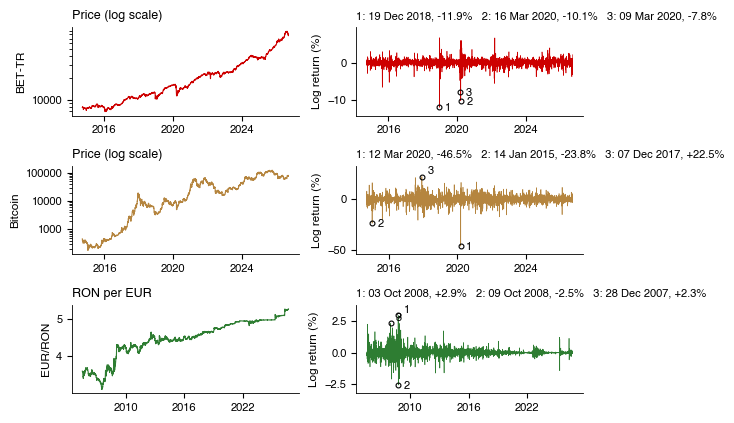

   saved ch1_sem_first_look


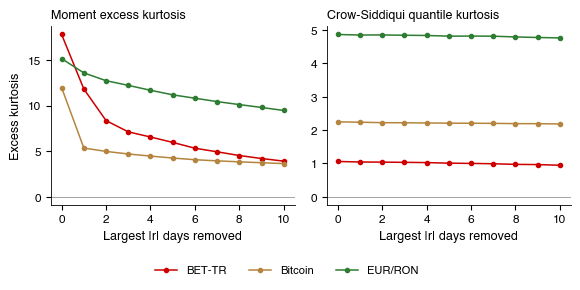

   saved ch1_sem_b1_sensitivity


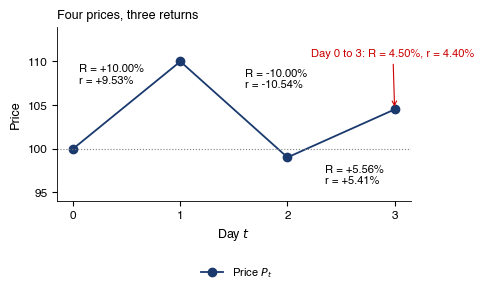

   saved ch1_sem_a1_path


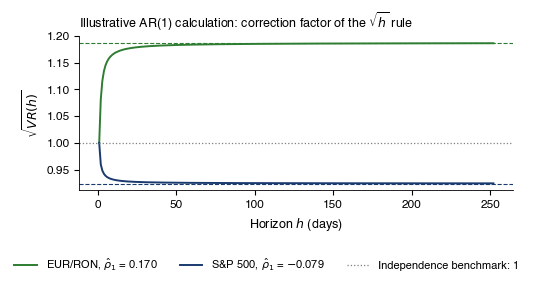

   saved ch1_sem_a2_vr


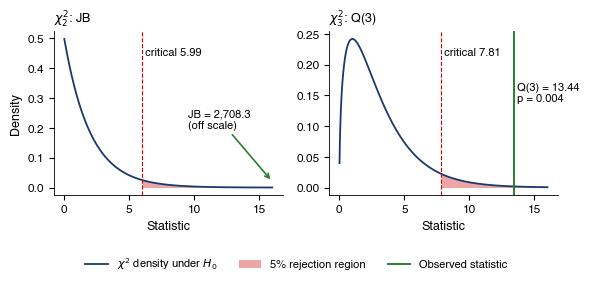

   saved ch1_sem_a3_chi2


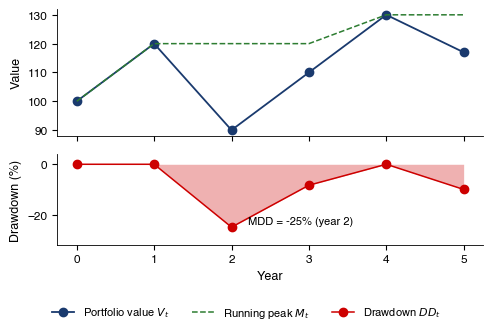

   saved ch1_sem_a4_drawdown


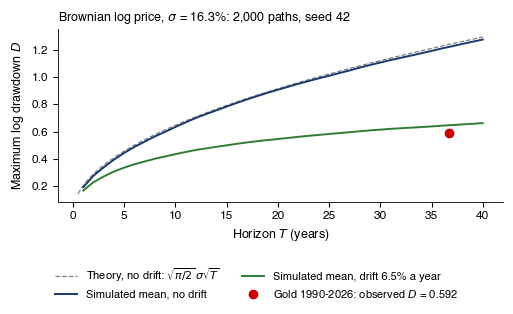

   saved ch1_sem_a4_brownian


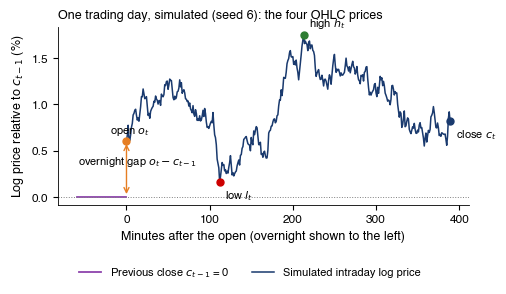

   saved ch1_sem_a5_ohlc


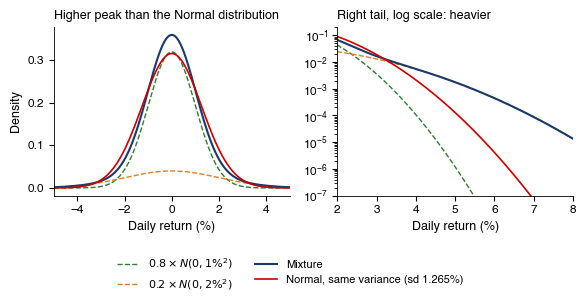

   saved ch1_sem_a6_mixture


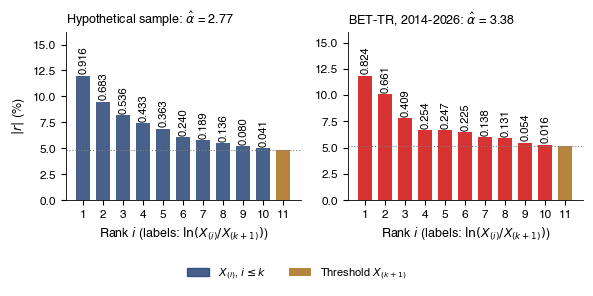

   saved ch1_sem_a7_hill


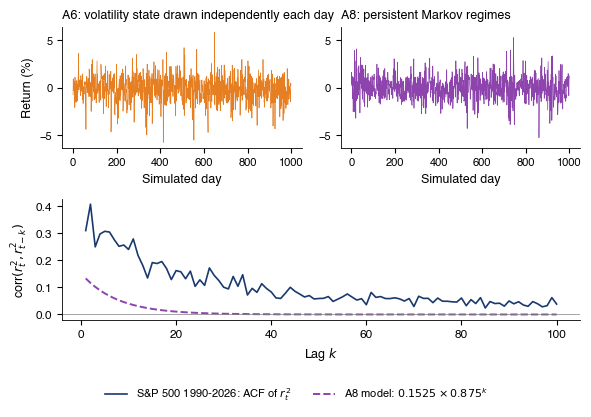

   saved ch1_sem_a8_regimes


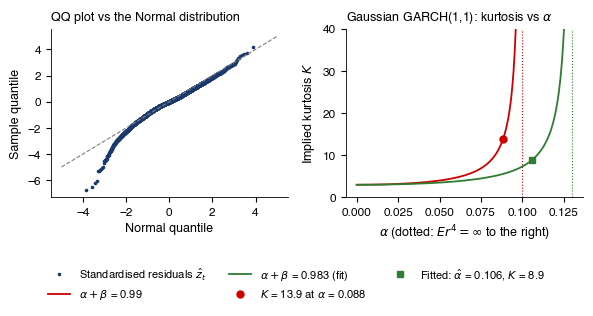

   saved ch1_sem_a9_garch


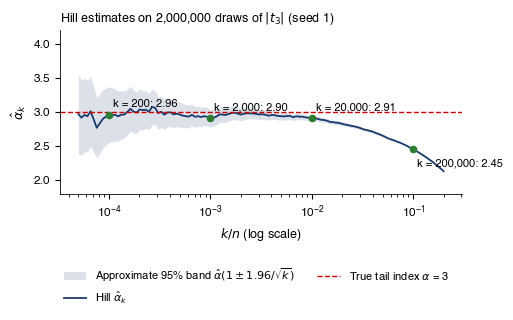

   saved ch1_sem_a11_hill_sim


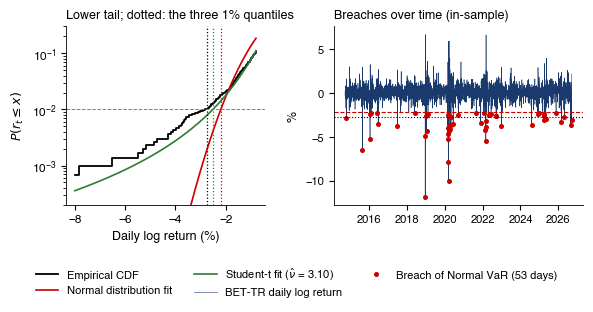

   saved ch1_sem_b2_var


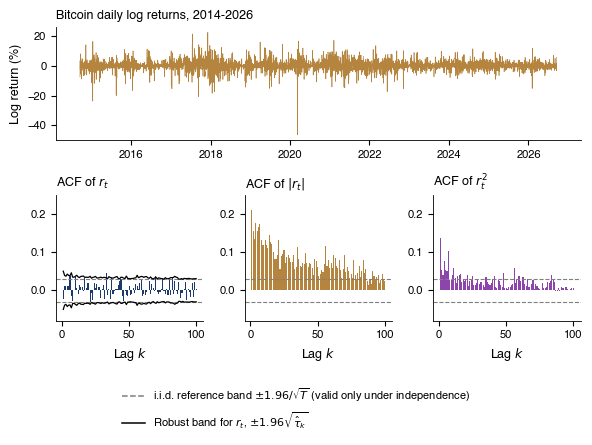

   saved ch1_sem_b3_acf


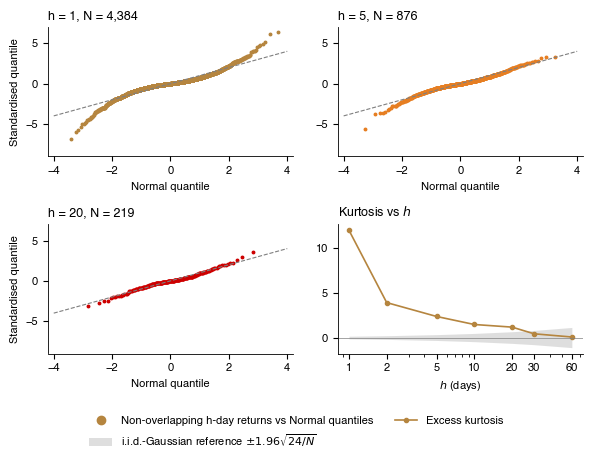

   saved ch1_sem_b4_qq


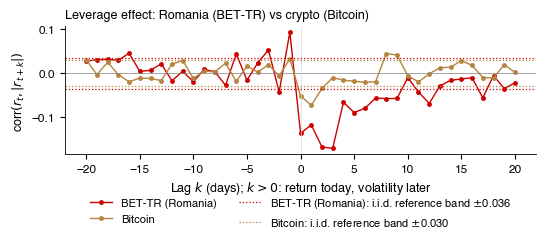

   saved ch1_sem_leverage_ro_crypto


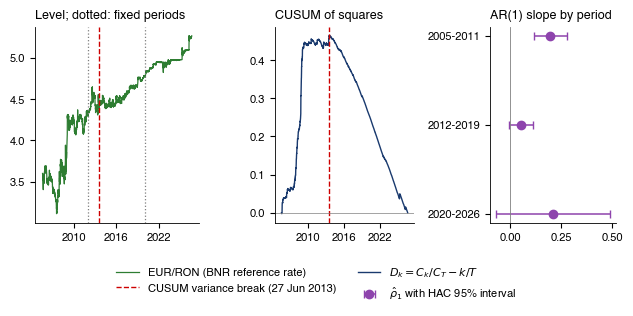

   saved ch1_sem_b6_regimes


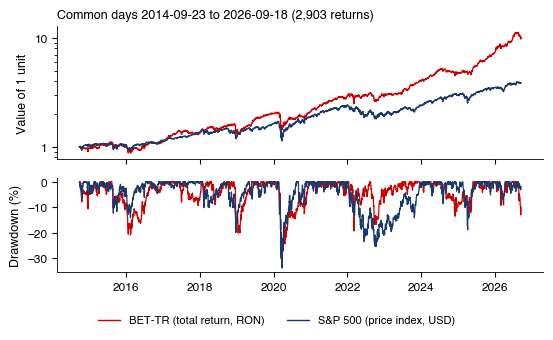

   saved ch1_sem_b7_wealth


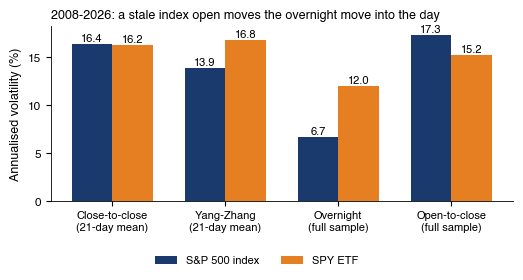

   saved ch1_sem_b8_index_spy


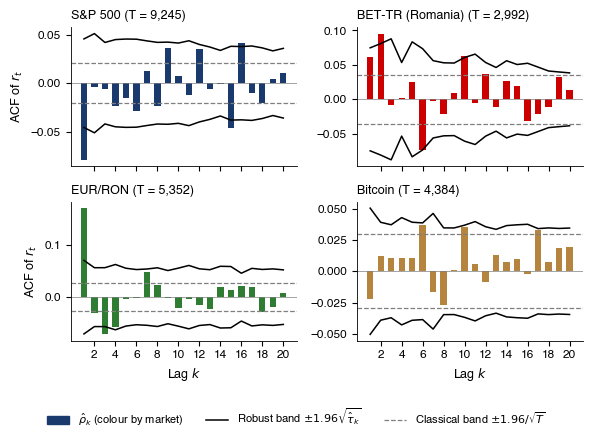

   saved ch1_sem_robust_acf


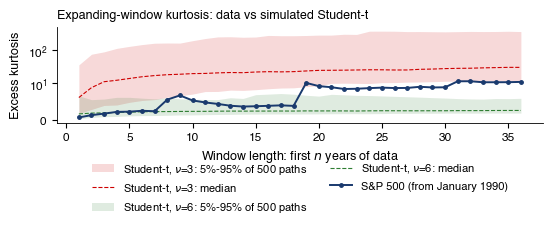

   saved ch1_sem_kurtosis_expanding


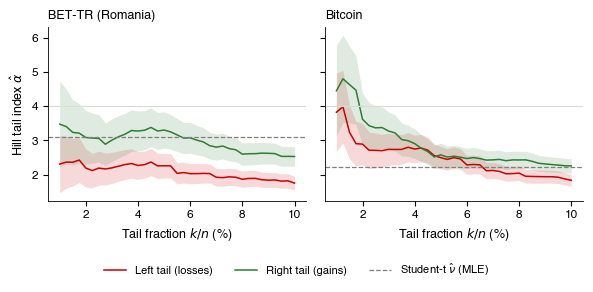

   saved ch1_sem_hill_tails


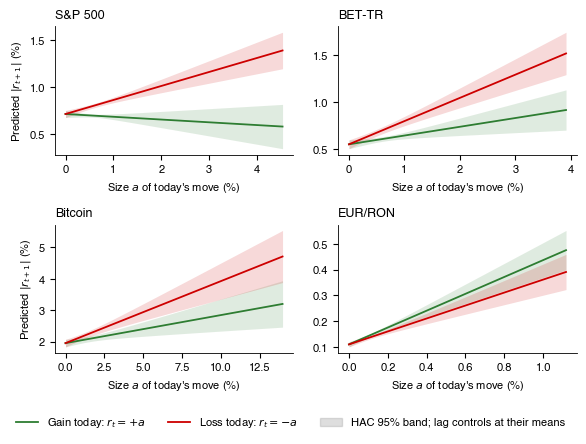

   saved ch1_sem_b12_response


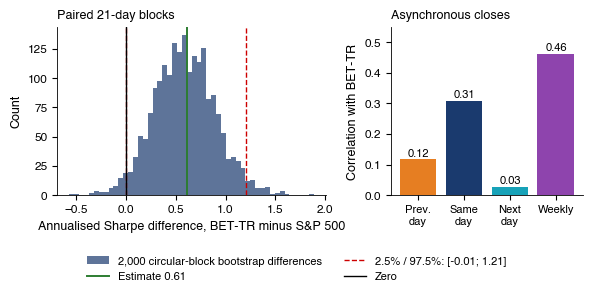

   saved ch1_sem_b13_bootstrap


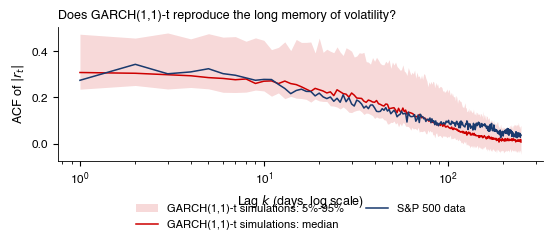

   saved ch1_sem_garch_check


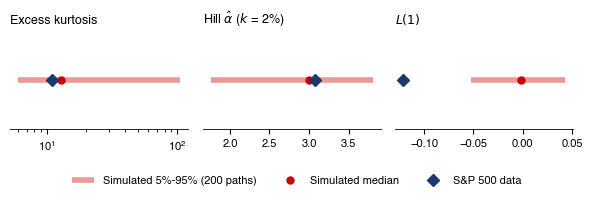

   saved ch1_sem_b14_facts


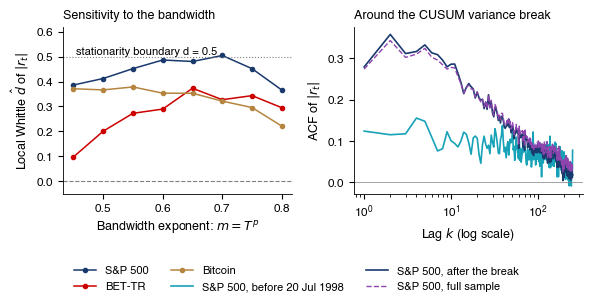

   saved ch1_sem_b15_memory


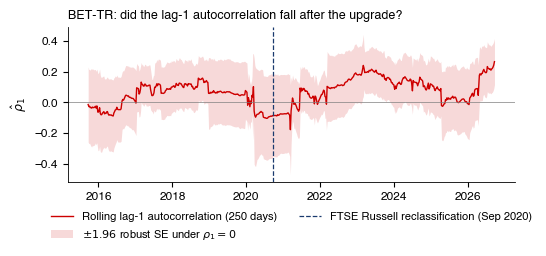

   saved ch1_sem_bettr_rolling_acf


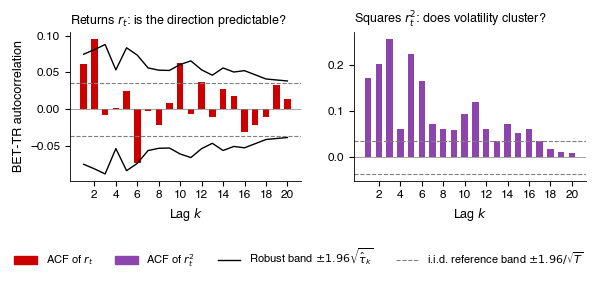

   saved ch1_sem_c2_acf
{'b1': {'bettr': {'JB': 40432.536738064795,
                  'JB_kurt_term': np.float64(39455.25044715632),
                  'JB_skew_term': np.float64(977.2862909084739),
                  'P': 252,
                  'T': 2992,
                  'ann_vol_pct': np.float64(15.51961553850759),
                  'cs_all': np.float64(1.0571599783099668),
                  'cs_drop5': np.float64(1.0056860291613874),
                  'exkurt': np.float64(17.79005244943534),
                  'exkurt_drop1': np.float64(11.811459922007705),
                  'exkurt_drop5': np.float64(5.954400190080058),
                  'largest': [('2018-12-19', -11.86), ('2020-03-16', -10.08), ('2020-03-09', -7.83),
                              ('2018-12-24', 6.71), ('2022-03-09', 6.66)],
                  'max_date': '2018-12-24',
                  'max_pct': 6.706696449602667,
                  'mean_pct': np.float64(0.07711608245458226),
                  'min_date': '2018-12

In [6]:
import pprint
R = run_all_seminar('seminar1_results.json')
pprint.pprint({k: R[k] for k in ('setup', 'b1', 'b2', 'b9', 'b13')}, width=120, compact=True)

![ch1_sem_first_look](./ch1_sem_first_look.png)

Output: `ch1_sem_first_look.pdf`

![ch1_sem_b1_sensitivity](./ch1_sem_b1_sensitivity.png)

Output: `ch1_sem_b1_sensitivity.pdf`

![ch1_sem_a1_path](./ch1_sem_a1_path.png)

Output: `ch1_sem_a1_path.pdf`

![ch1_sem_a2_vr](./ch1_sem_a2_vr.png)

Output: `ch1_sem_a2_vr.pdf`

![ch1_sem_a3_chi2](./ch1_sem_a3_chi2.png)

Output: `ch1_sem_a3_chi2.pdf`

![ch1_sem_a4_drawdown](./ch1_sem_a4_drawdown.png)

Output: `ch1_sem_a4_drawdown.pdf`

![ch1_sem_a4_brownian](./ch1_sem_a4_brownian.png)

Output: `ch1_sem_a4_brownian.pdf`

![ch1_sem_a5_ohlc](./ch1_sem_a5_ohlc.png)

Output: `ch1_sem_a5_ohlc.pdf`

![ch1_sem_a6_mixture](./ch1_sem_a6_mixture.png)

Output: `ch1_sem_a6_mixture.pdf`

![ch1_sem_a7_hill](./ch1_sem_a7_hill.png)

Output: `ch1_sem_a7_hill.pdf`

![ch1_sem_a8_regimes](./ch1_sem_a8_regimes.png)

Output: `ch1_sem_a8_regimes.pdf`

![ch1_sem_a9_garch](./ch1_sem_a9_garch.png)

Output: `ch1_sem_a9_garch.pdf`

![ch1_sem_a11_hill_sim](./ch1_sem_a11_hill_sim.png)

Output: `ch1_sem_a11_hill_sim.pdf`

![ch1_sem_b2_var](./ch1_sem_b2_var.png)

Output: `ch1_sem_b2_var.pdf`

![ch1_sem_b3_acf](./ch1_sem_b3_acf.png)

Output: `ch1_sem_b3_acf.pdf`

![ch1_sem_b4_qq](./ch1_sem_b4_qq.png)

Output: `ch1_sem_b4_qq.pdf`

![ch1_sem_leverage_ro_crypto](./ch1_sem_leverage_ro_crypto.png)

Output: `ch1_sem_leverage_ro_crypto.pdf`

![ch1_sem_b6_regimes](./ch1_sem_b6_regimes.png)

Output: `ch1_sem_b6_regimes.pdf`

![ch1_sem_b7_wealth](./ch1_sem_b7_wealth.png)

Output: `ch1_sem_b7_wealth.pdf`

![ch1_sem_b8_index_spy](./ch1_sem_b8_index_spy.png)

Output: `ch1_sem_b8_index_spy.pdf`

![ch1_sem_robust_acf](./ch1_sem_robust_acf.png)

Output: `ch1_sem_robust_acf.pdf`

![ch1_sem_kurtosis_expanding](./ch1_sem_kurtosis_expanding.png)

Output: `ch1_sem_kurtosis_expanding.pdf`

![ch1_sem_hill_tails](./ch1_sem_hill_tails.png)

Output: `ch1_sem_hill_tails.pdf`

![ch1_sem_b12_response](./ch1_sem_b12_response.png)

Output: `ch1_sem_b12_response.pdf`

![ch1_sem_b13_bootstrap](./ch1_sem_b13_bootstrap.png)

Output: `ch1_sem_b13_bootstrap.pdf`

![ch1_sem_garch_check](./ch1_sem_garch_check.png)

Output: `ch1_sem_garch_check.pdf`

![ch1_sem_b14_facts](./ch1_sem_b14_facts.png)

Output: `ch1_sem_b14_facts.pdf`

![ch1_sem_b15_memory](./ch1_sem_b15_memory.png)

Output: `ch1_sem_b15_memory.pdf`

![ch1_sem_bettr_rolling_acf](./ch1_sem_bettr_rolling_acf.png)

Output: `ch1_sem_bettr_rolling_acf.pdf`

![ch1_sem_c2_acf](./ch1_sem_c2_acf.png)

Output: `ch1_sem_c2_acf.pdf`